#Project Title :
#Stratified Risk Profiling and Cognitive Decline Patterns in Alzheimer’s Disease Using NACC-UDS Data
#Vaishnavi Tiwari


In [ ]:
pip install numpy pandas matplotlib seaborn scipy scikit-learn statsmodels missingno sweetviz pandas-profiling ydata-profiling scikit-learn-extra imbalanced-learn shap

  Using cached sweetviz-2.3.1-py3-none-any.whl.metadata (24 kB)
  Using cached pandas_profiling-3.2.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached ydata_profiling-4.18.1-py2.py3-none-any.whl.metadata (22 kB)
INFO: pip is looking at multiple versions of pandas-profiling to determine which version is compatible with other requirements. This could take a while.
  Using cached pandas_profiling-3.1.0-py2.py3-none-any.whl.metadata (23 kB)
  Using cached pandas_profiling-3.0.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached visions-0.7.1-py3-none-any.whl.metadata (5.5 kB)
  Using cached htmlmin-0.1.12.tar.gz (19 kB)
  Preparing metadata (setup.py) ... done
  Using cached phik-0.12.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached tangled_up_in_unicode-0.1.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached multimethod-1.4-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
INFO: 

In [ ]:
!pip install scikit-learn-extra -q

In [ ]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

CSV_PATH     = "/content/drive/MyDrive/investigator_nacc72.csv"
PARQUET_PATH = "/content/drive/MyDrive/investigator_nacc72.parquet"

if os.path.exists(PARQUET_PATH):
    print(f"Parquet already exists at:\n   {PARQUET_PATH}")
    print("   Skipping conversion. Go to Step 2.")
else:
    print("Reading CSV")
    df_raw = pd.read_csv(CSV_PATH, low_memory=False)
    print(f"   CSV loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")

    print("Saving as Parquet...")
    df_raw.to_parquet(PARQUET_PATH, index=False)
    print(f"Parquet saved!")
    print(f"   Location : {PARQUET_PATH}")
    print(f"   File size: {os.path.getsize(PARQUET_PATH)/1e6:.1f} MB")

print(f"   df_raw = pd.read_parquet('{PARQUET_PATH}')")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Parquet already exists at:
   /content/drive/MyDrive/investigator_nacc72.parquet
   Skipping conversion. Go to Step 2.
   df_raw = pd.read_parquet('/content/drive/MyDrive/investigator_nacc72.parquet')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PARQUET_PATH = "/content/drive/MyDrive/investigator_nacc72.parquet"

print("Loading from Parquet...")
df_raw = pd.read_parquet(PARQUET_PATH)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")

# 1) SELECT COLUMNS
keep_cols = [
    "NACCID", "NACCVNUM", "VISITYR", "VISITMO", "VISITDAY", "NACCFDYS",
    "NACCAGE", "SEX", "EDUC", "RACE", "HISPANIC",
    "NACCMMSE", "NACCMOCA", "NACCUDSD",
    "DEPDSEV", "ANXSEV", "APASEV", "AGITSEV",
    "DIABETES", "HYPERTEN",
    "NACCAPOE", "NACCNE4S"
]
keep_cols = [c for c in keep_cols if c in df_raw.columns]
df = df_raw[keep_cols].copy()
print(f"Working columns: {df.shape[1]}")

# 2) STANDARDIZE TYPES
df["NACCID"] = df["NACCID"].astype("string")
for c in [col for col in df.columns if col != "NACCID"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) CLEAN NACC MISSING CODES
NACC_MISSING = [-1, -2, -3, -4, -6, -7, -8, -9, -99, -999]
clean_cols = [c for c in df.columns if c != "NACCID"]
df[clean_cols] = df[clean_cols].replace(NACC_MISSING, np.nan)

if "NACCMOCA" in df.columns:
    df["NACCMOCA"] = df["NACCMOCA"].replace([88, 99], np.nan)
if "NACCMMSE" in df.columns:
    df["NACCMMSE"] = df["NACCMMSE"].replace([88, 95, 96, 97, 98], np.nan)

# Coded unknowns -> NaN (kept as separate clean columns)
for col, bad in [("EDUC", [99]), ("RACE", [99]), ("HISPANIC", [9])]:
    if col in df.columns:
        df[f"{col}_clean"] = df[col].mask(df[col].isin(bad), np.nan)

# Genetic missing
for col in ["NACCAPOE", "NACCNE4S"]:
    if col in df.columns:
        df[col] = df[col].replace(9, np.nan)

# 4) BUILD VISIT DATE + VISIT ORDER
if {"VISITYR", "VISITMO", "VISITDAY"}.issubset(df.columns):
    df["VISIT_DATE"] = pd.to_datetime(
        dict(year=df["VISITYR"], month=df["VISITMO"], day=df["VISITDAY"]),
        errors="coerce"
    )
else:
    df["VISIT_DATE"] = pd.NaT

df = df.sort_values(["NACCID", "VISIT_DATE", "NACCVNUM"])
df["VISIT_ORDER"] = df.groupby("NACCID").cumcount() + 1

print(f"Date range: {df['VISIT_DATE'].min().date()} to {df['VISIT_DATE'].max().date()}")


Loading from Parquet...
Loaded: 207,454 rows x 1,024 columns
Working columns: 22
Date range: 2005-06-09 to 2025-10-21


207,454 rows, 22 columns, date range looks clean


TARGET VARIABLE: NACCUDSD
Visit-level counts (all visits):
NACCUDSD
1    101837
2      9184
3     36637
4     59796
Name: count, dtype: int64

Person-level counts (baseline visit only):
NACCUDSD
1    22863
2     2496
3    12466
4    17443
Name: count, dtype: int64


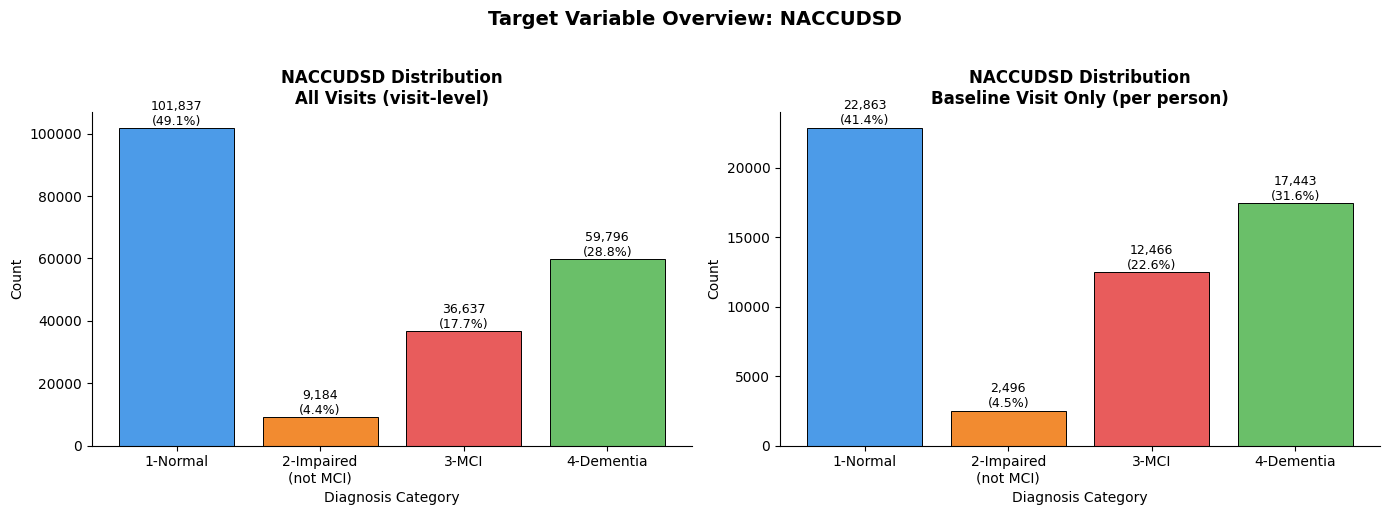

In [ ]:
# 5) TARGET VARIABLE: NACCUDSD
# NACCUDSD coding:
#   1 = Cognitively Normal
#   2 = Impaired, not MCI
#   3 = MCI
#   4 = Dementia
UDSD_LABELS = {1: "1-Normal", 2: "2-Impaired\n(not MCI)", 3: "3-MCI", 4: "4-Dementia"}
df["NACCUDSD_cat"] = df["NACCUDSD"].map(UDSD_LABELS).astype("category")

print("\nTARGET VARIABLE: NACCUDSD")
print("Visit-level counts (all visits):")
print(df["NACCUDSD"].value_counts(dropna=False).sort_index())

# Baseline = first visit per person
baseline = (
    df.sort_values(["NACCID", "VISIT_ORDER"])
    .groupby("NACCID", observed=True)
    .first()
    .reset_index()
)
print("\nPerson-level counts (baseline visit only):")
print(baseline["NACCUDSD"].value_counts(dropna=False).sort_index())

# Plot: Target distribution
colors = ["#4C9BE8", "#F28B30", "#E85C5C", "#6ABF69"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(
    axes,
    [df, baseline],
    ["All Visits (visit-level)", "Baseline Visit Only (per person)"]
):
    counts = data["NACCUDSD"].value_counts(dropna=False).sort_index()
    bars = ax.bar(
        [UDSD_LABELS.get(k, str(k)) for k in counts.index],
        counts.values,
        color=colors[:len(counts)],
        edgecolor="black", linewidth=0.7
    )
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{val:,}\n({val/counts.sum()*100:.1f}%)",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"NACCUDSD Distribution\n{title}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Diagnosis Category")
    ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Target Variable Overview: NACCUDSD", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


Visit-level (207,454 visits):

Normal: 101,837 (49%) — nearly half the data
Dementia: 59,796 (29%)
MCI: 36,637 (18%)
Impaired-not-MCI: 9,184 (4%) — smallest group, will be tricky to model

Person-level (55,268 people):

Normal: 22,863 (41%)
Dementia: 17,443 (32%)
MCI: 12,466 (23%)
Impaired-not-MCI: 2,496 (4%) — confirmed minority class



MISSINGNESS (all columns)


,missing_rate
NACCMOCA,0.638792
NACCMMSE,0.520520
HYPERTEN,0.391292
DIABETES,0.391292
NACCAPOE,0.137187
NACCNE4S,0.137187
DEPDSEV,0.064612
ANXSEV,0.064000
APASEV,0.063952
AGITSEV,0.062718


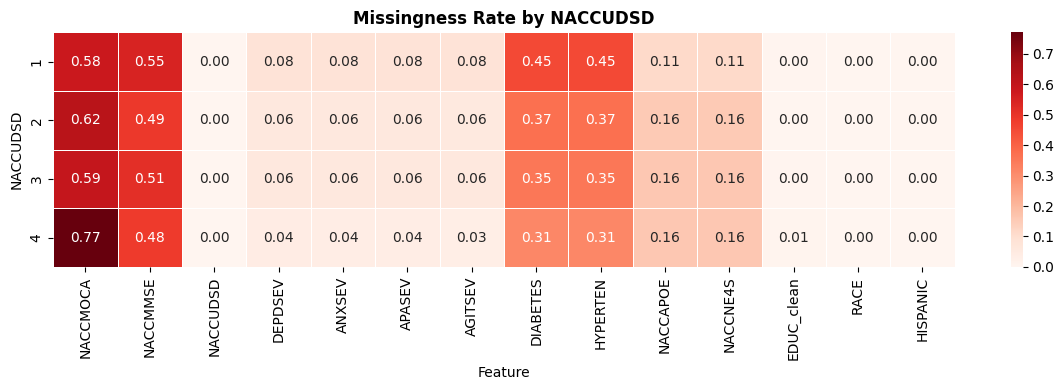

In [ ]:
# 6) OVERALL MISSINGNESS
print("\nMISSINGNESS (all columns)")
miss = df.isna().mean().sort_values(ascending=False)
display(miss[miss > 0].rename("missing_rate").to_frame())

focus_cols = [c for c in [
    "NACCMOCA","NACCMMSE","NACCUDSD","DEPDSEV","ANXSEV",
    "APASEV","AGITSEV","DIABETES","HYPERTEN",
    "NACCAPOE","NACCNE4S","EDUC_clean","RACE","HISPANIC"
] if c in df.columns]

miss_by_udsd = (
    df.groupby("NACCUDSD", observed=True)[focus_cols]
    .apply(lambda g: g.isna().mean())
    .sort_index()
)
plt.figure(figsize=(12, 4))
sns.heatmap(miss_by_udsd, annot=True, fmt=".2f", cmap="Reds", linewidths=0.5)
plt.title("Missingness Rate by NACCUDSD", fontsize=12, fontweight="bold")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()


Key findings:
MoCA (58 to 77% missing): this is the biggest issue. Dementia group (4) has 77% missing, which makes sense clinically since severely impaired patients often can't complete MoCA. This means MoCA alone can't be the primary feature for modeling, we'll need MMSE as the fallback.
MMSE (48 to 55% missing): also high but more consistent across groups, less biased.
Diabetes + Hypertension (31 to 45% missing): high enough that we should either impute carefully or flag as a binary "recorded vs not recorded" variable.
NACCAPOE + NACCNE4S (11 to 16% missing): manageable, and these are genetically important features worth keeping.
Behavioral symptoms (DEPDSEV, ANXSEV, APASEV, AGITSEV): only 4 to 8% missing, these are the most complete and reliable features.
Demographics (EDUC, RACE, HISPANIC): near 0% missing, clean.

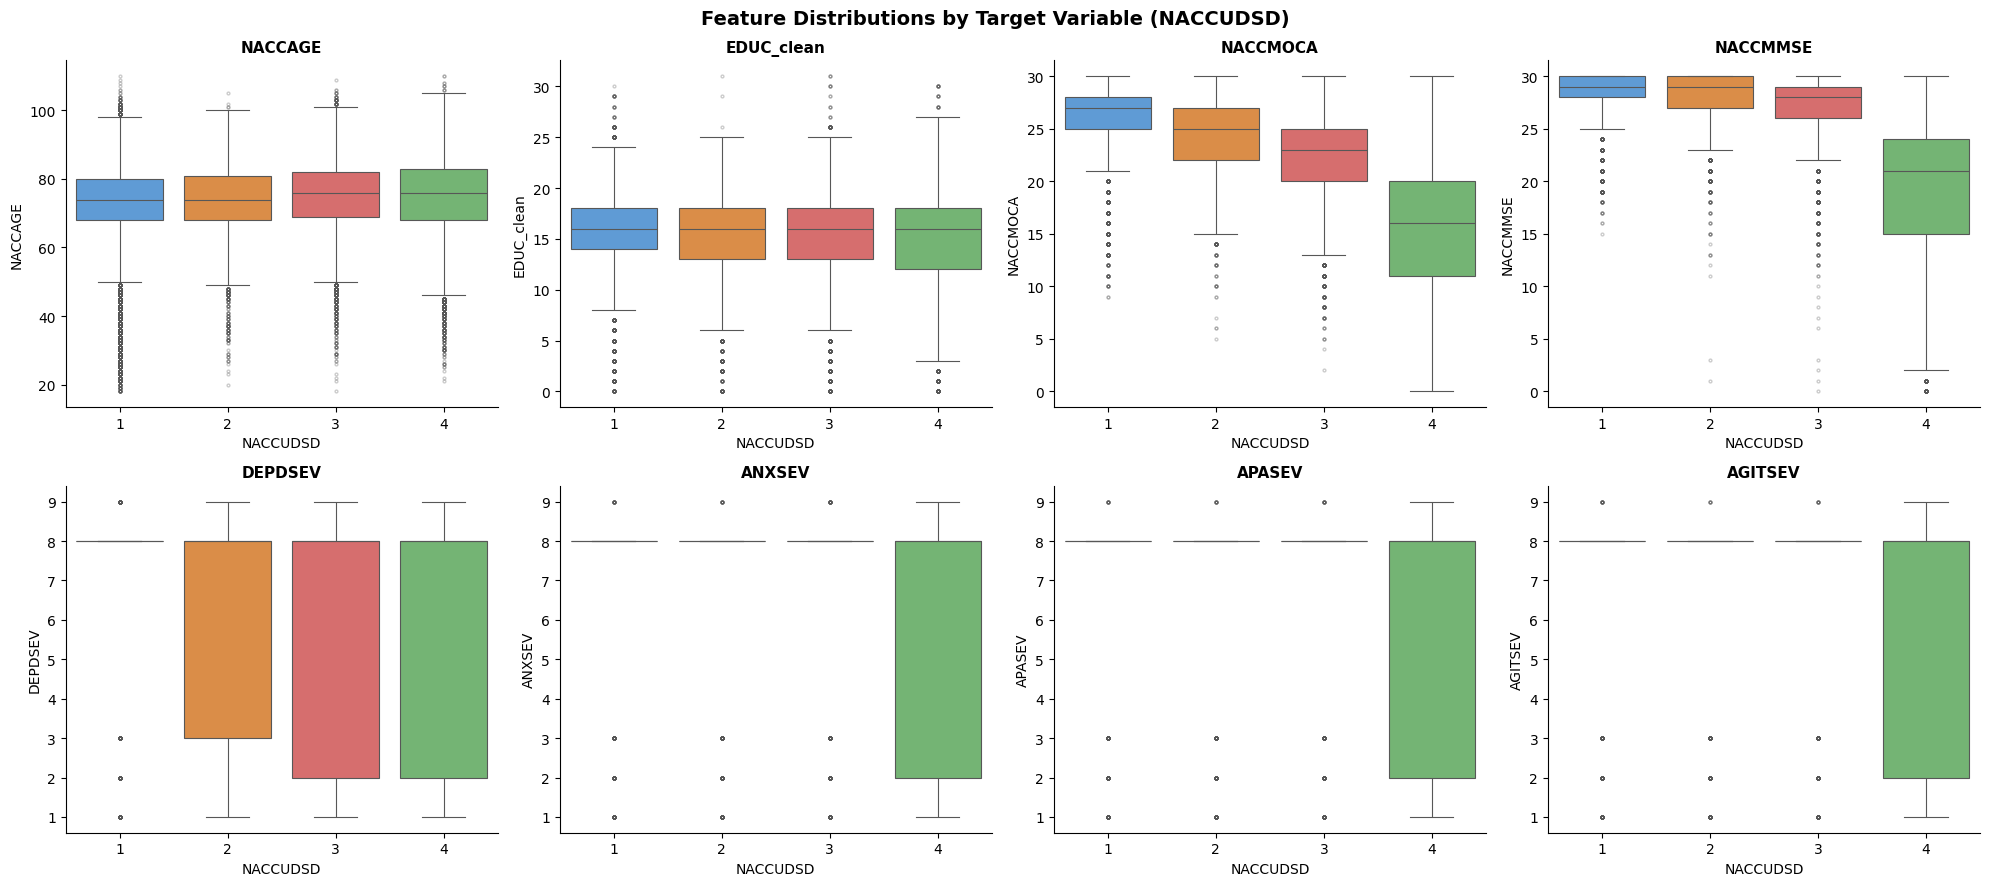


 MEAN FEATURE VALUES BY NACCUDSD 


,NACCAGE,EDUC_clean,NACCMOCA,NACCMMSE,DEPDSEV,ANXSEV,APASEV,AGITSEV
NACCUDSD,,,,,,,,
1,73.46,16.05,26.50,28.91,7.15,7.36,7.71,7.65
2,73.70,15.28,24.40,28.00,6.30,6.66,7.06,7.04
3,75.52,15.50,22.52,27.03,6.09,6.41,6.81,6.87
4,75.13,14.91,14.99,19.18,5.56,5.36,4.98,5.59


In [ ]:
# 7) FEATURE DISTRIBUTIONS BY NACCUDSD (what drives the target)
eda_feature_cols = [c for c in [
    "NACCAGE", "EDUC_clean", "NACCMOCA", "NACCMMSE",
    "DEPDSEV", "ANXSEV", "APASEV", "AGITSEV"
] if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(eda_feature_cols):
    plot_data = df.dropna(subset=["NACCUDSD", col]).copy()
    plot_data["NACCUDSD"] = plot_data["NACCUDSD"].astype(int).astype(str)
    sns.boxplot(
        data=plot_data, x="NACCUDSD", y=col,
        hue="NACCUDSD",
        order=["1","2","3","4"],
        palette={"1":"#4C9BE8","2":"#F28B30","3":"#E85C5C","4":"#6ABF69"},
        ax=axes[i], linewidth=0.8, legend=False,
        flierprops=dict(marker="o", markersize=2, alpha=0.3)
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("NACCUDSD")
    axes[i].spines[["top","right"]].set_visible(False)

plt.suptitle("Feature Distributions by Target Variable (NACCUDSD)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Mean feature value per NACCUDSD group
print("\n MEAN FEATURE VALUES BY NACCUDSD ")
summary = df.groupby("NACCUDSD", observed=True)[eda_feature_cols].mean().round(2)
display(summary)

From the boxplots:
MoCA and MMSE tell a clear story. The boxes shift visibly downward from group 1
to group 4, with group 4 (Dementia) sitting noticeably lower with a much wider
spread. That wide spread in the Dementia box for MoCA means some dementia patients
still score relatively high, showing heterogeneity within the group.

The behavioral symptom plots show groups 1, 2, 3 clustering toward the low end
of the scale, symptoms are mostly absent. Group 4 (Dementia) has a much wider
spread, indicating dementia patients show highly variable behavioral symptom
severity, some have none, others have severe symptoms.

From the mean table:
The clearest takeaway is the jump at group 4. MoCA drops from 22.52 (MCI) to
14.99 (Dementia), that is a 7.5 point cliff. MMSE drops from 27.03 to 19.18,
an 8 point cliff. Both scores decline gradually from groups 1 to 3, then fall
sharply at 4. That sharp cliff is the most important finding from these two
images. Dementia is qualitatively different from MCI, not just a continuation
of the same gradient.

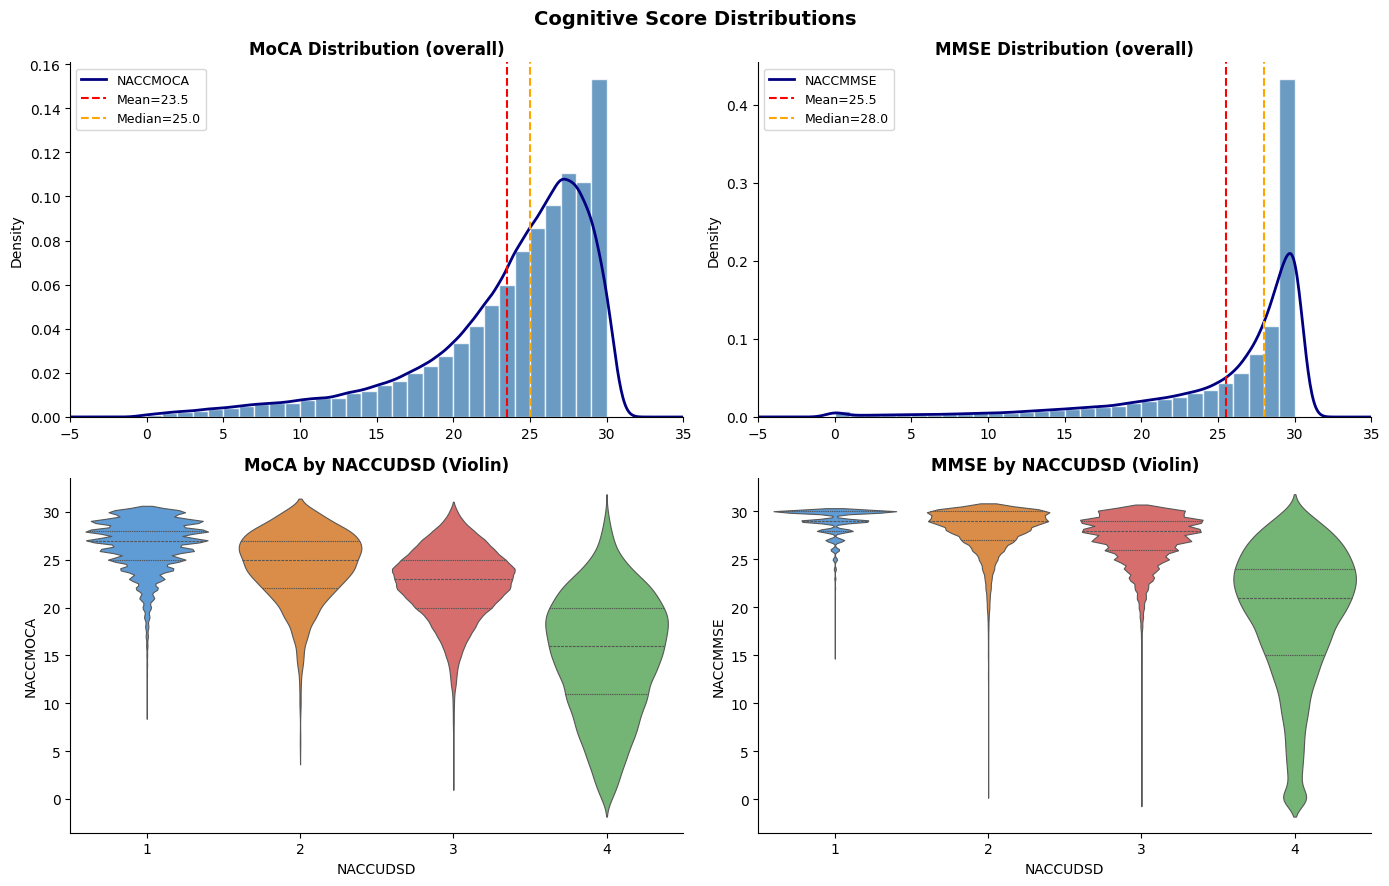

MoCA  — mean: 23.5, median: 25.0
MMSE  — mean: 25.5, median: 28.0


In [ ]:
# 8) COGNITIVE SCORE DISTRIBUTIONS (MoCA + MMSE)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top row: histograms + KDE
for ax, col, title in zip(
    [axes[0,0], axes[0,1]],
    ["NACCMOCA", "NACCMMSE"],
    ["MoCA Distribution (overall)", "MMSE Distribution (overall)"]
):
    if col in df.columns:
        data = df[col].dropna()
        ax.hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.8, density=True)
        data.plot(kind="kde", ax=ax, color="navy", linewidth=2)
        ax.axvline(data.mean(), color="red", linestyle="--", label=f"Mean={data.mean():.1f}")
        ax.axvline(data.median(), color="orange", linestyle="--", label=f"Median={data.median():.1f}")
        ax.set_title(title, fontweight="bold")
        ax.set_xlim(-5, 35)   # fix axis to valid score range
        ax.legend(fontsize=9)
        ax.spines[["top","right"]].set_visible(False)

# Bottom row: violin plots - fix palette key type same as section 7
pal_str = {"1":"#4C9BE8", "2":"#F28B30", "3":"#E85C5C", "4":"#6ABF69"}

for ax, col, title in zip(
    [axes[1,0], axes[1,1]],
    ["NACCMOCA", "NACCMMSE"],
    ["MoCA by NACCUDSD (Violin)", "MMSE by NACCUDSD (Violin)"]
):
    if {"NACCUDSD", col}.issubset(df.columns):
        plot_data = df.dropna(subset=["NACCUDSD", col]).copy()
        plot_data["NACCUDSD"] = plot_data["NACCUDSD"].astype(int).astype(str)
        sns.violinplot(
            data=plot_data, x="NACCUDSD", y=col,
            hue="NACCUDSD",
            order=["1","2","3","4"],
            palette=pal_str,
            ax=ax, inner="quartile", linewidth=0.8, legend=False
        )
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("NACCUDSD")
        ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Cognitive Score Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"MoCA  — mean: {df['NACCMOCA'].mean():.1f}, median: {df['NACCMOCA'].median():.1f}")
print(f"MMSE  — mean: {df['NACCMMSE'].mean():.1f}, median: {df['NACCMMSE'].median():.1f}")

Top row, Overall distributions:
Both MoCA and MMSE are heavily left-skewed. The bulk of scores pile up at the top (25 to 30) with a long tail dragging left toward zero. This makes sense, most patients in the cohort are cognitively normal or mildly impaired, so high scores dominate. The mean sits notably below the median for both (MoCA: mean 23.5 vs median 25.0, MMSE: mean 25.5 vs median 28.0), which confirms that tail of low-scoring dementia patients is pulling the mean down.

Bottom row, Violin plots by NACCUDSD:
This is the most informative part of the image. Reading left to right:
Groups 1, 2, 3 (Normal, Impaired, MCI): all three violins are narrow and top-heavy, meaning scores are tightly clustered near the maximum. The progression from 1 to 2 to 3 is gradual and the shapes look similar.
Group 4 (Dementia): completely different shape. The violin is wide, fat in the middle, and spreads all the way down toward zero. This tells us dementia patients are all over the map, some score near 25, others near 0. That wide spread is clinically meaningful, dementia severity varies enormously within the diagnosis.
The key insight: Groups 1 to 3 are hard to separate from cognitive scores alone because their distributions heavily overlap. Group 4 is the only one that truly stands apart. This has a direct implication for Phase 3, a binary Normal vs Dementia classifier will work much better than a 4-class model.

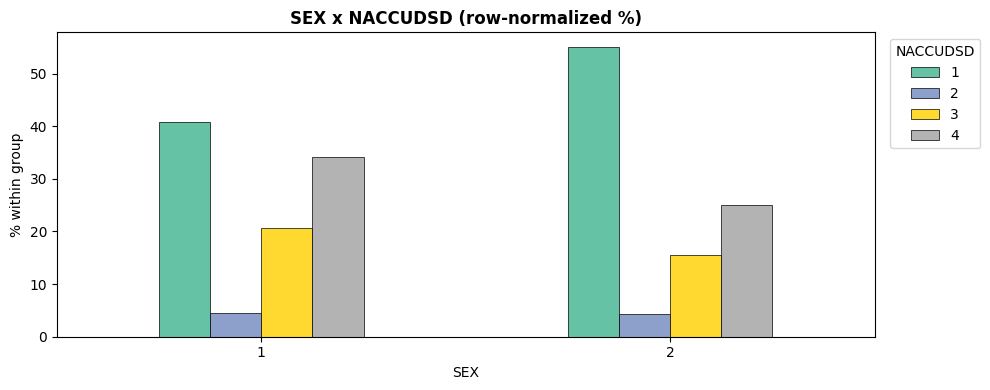

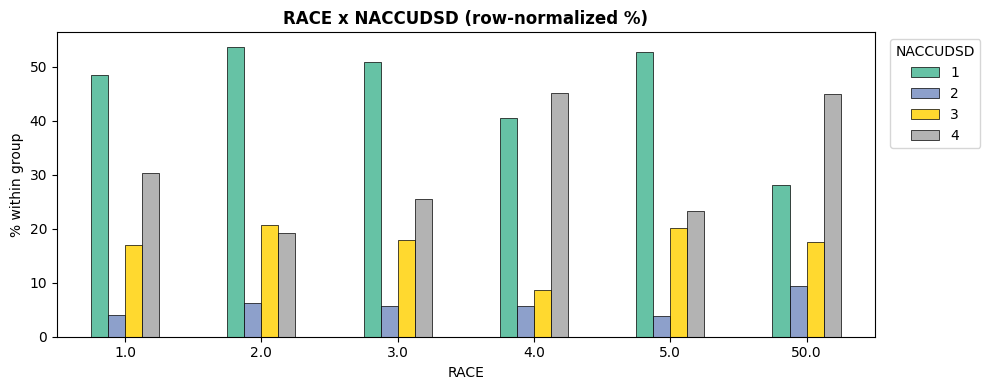

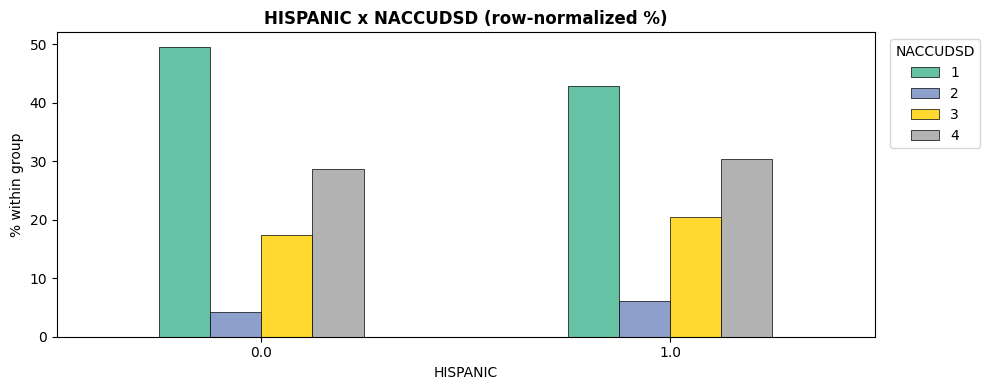

In [ ]:
# 9) DEMOGRAPHIC BREAKDOWN BY NACCUDSD
demo_map = {
    "SEX": "SEX",
    "RACE": "RACE_clean" if "RACE_clean" in df.columns else "RACE",
    "HISPANIC": "HISPANIC_clean" if "HISPANIC_clean" in df.columns else "HISPANIC"
}

for label, col in demo_map.items():
    plot_data = df.dropna(subset=[col, "NACCUDSD"]).copy()
    plot_data["NACCUDSD"] = plot_data["NACCUDSD"].astype(int).astype(str)
    ct = pd.crosstab(plot_data[col], plot_data["NACCUDSD"], normalize="index") * 100
    ct.plot(kind="bar", figsize=(10, 4), colormap="Set2", edgecolor="black", linewidth=0.5)
    plt.title(f"{label} x NACCUDSD (row-normalized %)", fontweight="bold")
    plt.xlabel(label)
    plt.ylabel("% within group")
    plt.legend(title="NACCUDSD", bbox_to_anchor=(1.01,1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

SEX:
SEX=1 is male, SEX=2 is female. The difference is notable, males have 41% Normal and 34% Dementia, while females have 55% Normal and only 25% Dementia. This means women in this cohort are more likely to be cognitively normal at their visits than men. However this could reflect selection bias, women may be more likely to attend follow-up visits even when healthy, inflating their Normal count.

RACE:
The RACE codes are 1=White, 2=Black, 3=Other, 4=Asian, 5=Native Hawaiian/Pacific Islander, 50=Multiracial. The most striking finding is Race 4 (Asian) and Race 50 (Multiracial) have the highest Dementia proportions at 45%, while Race 2 (Black) and Race 5 have the highest Normal proportions (53%). Race is showing meaningful variation across groups, this is worth including as a feature in Phase 3. However the sample sizes for races 4, 5, and 50 are likely small so interpret with caution.

HISPANIC:
The pattern is almost identical between Hispanic and Non-Hispanic patients. Both groups show roughly 50% Normal, 18 to 20% MCI, 29 to 30% Dementia, and 4 to 6% Impaired-not-MCI. The distributions barely shift between the two groups, which means Hispanic ethnicity is not a meaningful differentiator of cognitive status in this cohort. The sample is likely majority Non-Hispanic which limits that comparison.

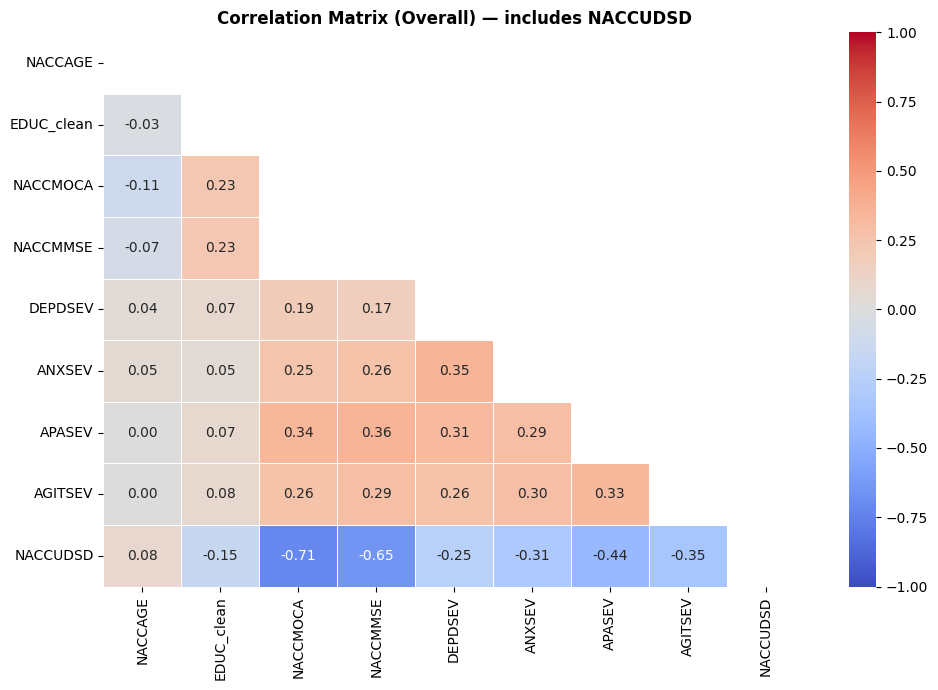

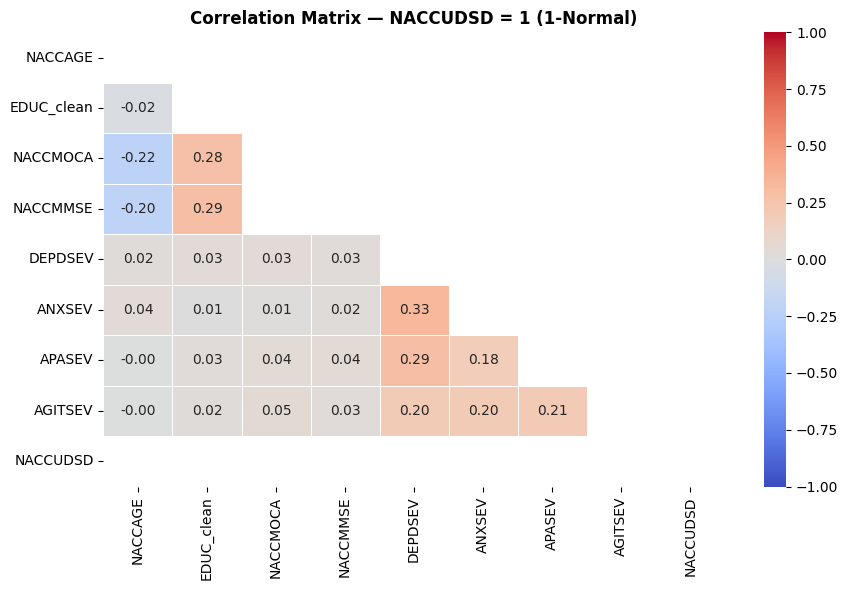

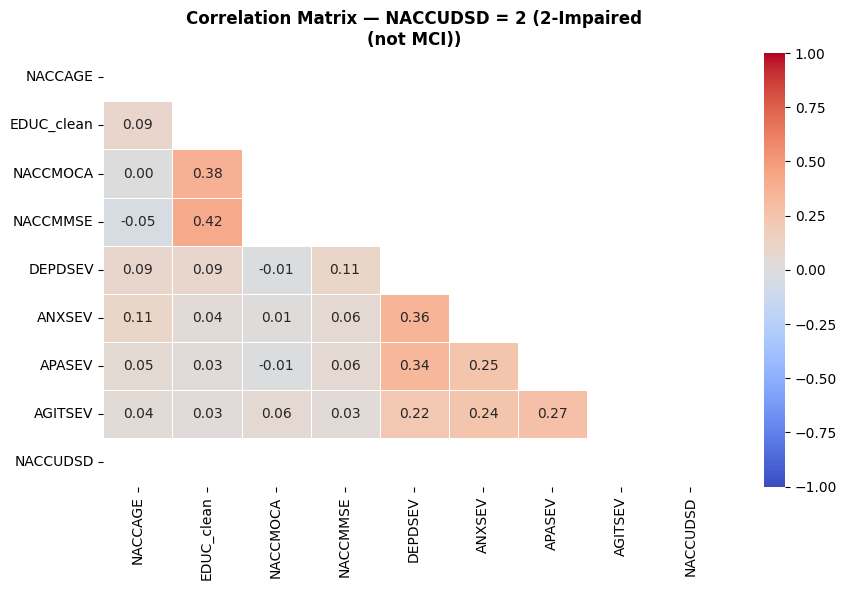

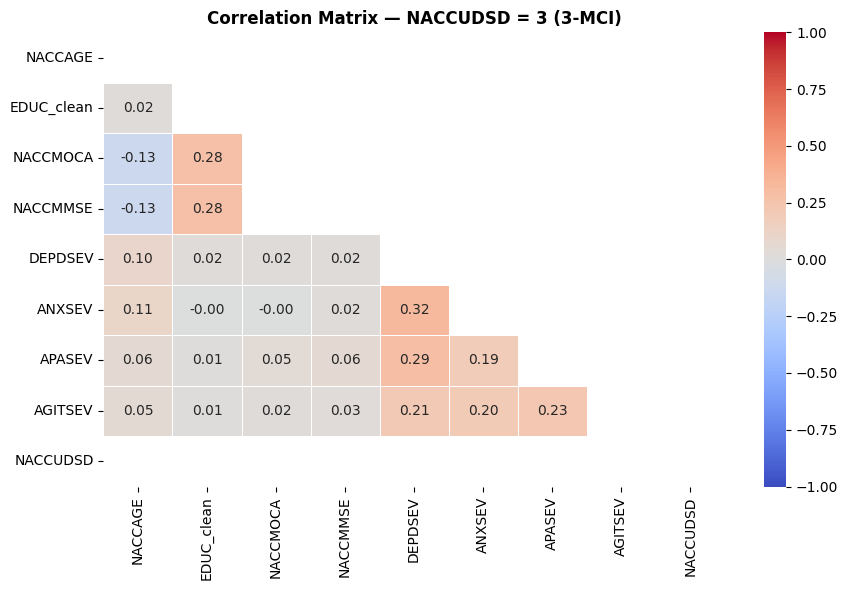

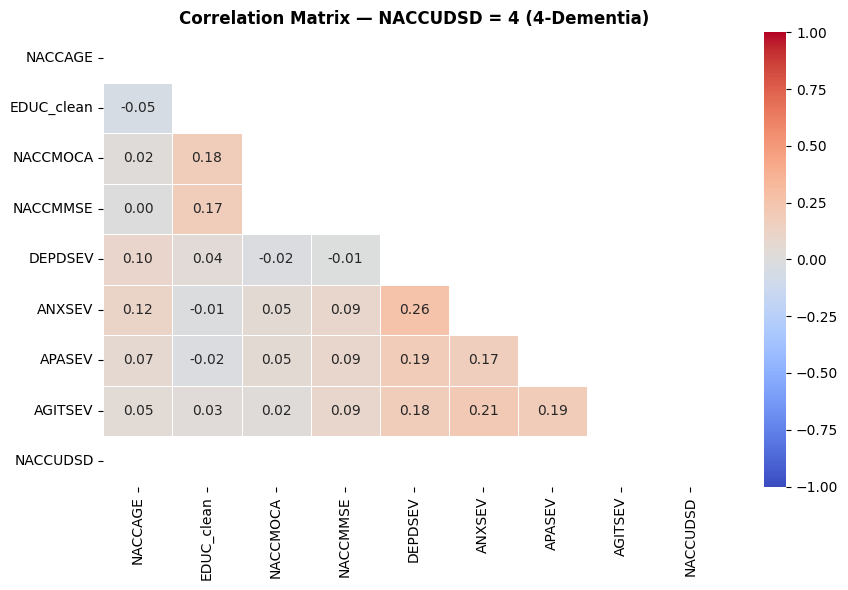

In [ ]:
# 10) CORRELATION MATRIX (OVERALL + BY NACCUDSD)
num_cols = [c for c in [
    "NACCAGE","EDUC_clean","NACCMOCA","NACCMMSE",
    "DEPDSEV","ANXSEV","APASEV","AGITSEV","NACCUDSD"
] if c in df.columns]

plt.figure(figsize=(10, 7))
corr = df[num_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix (Overall) — includes NACCUDSD", fontweight="bold")
plt.tight_layout()
plt.show()

for grp, g in df.dropna(subset=["NACCUDSD"]).groupby("NACCUDSD", observed=True):
    if len(g) < 200:
        continue
    plt.figure(figsize=(9, 6))
    corr_g = g[num_cols].corr(numeric_only=True)
    mask_g = np.triu(np.ones_like(corr_g, dtype=bool))
    sns.heatmap(corr_g, annot=True, fmt=".2f", cmap="coolwarm",
                mask=mask_g, linewidths=0.5, vmin=-1, vmax=1)
    plt.title(f"Correlation Matrix — NACCUDSD = {int(grp)} ({UDSD_LABELS.get(int(grp),'')})",
              fontweight="bold")
    plt.tight_layout()
    plt.show()

Overall Matrix:

NACCMOCA and NACCUDSD correlate at -0.71 and NACCMMSE at -0.65. These are by far the strongest relationships in the entire dataset. The negative sign is expected — higher cognitive scores mean lower (better) disease status number. Everything else is modest. APASEV has -0.44 with NACCUDSD which is stronger than expected — worth keeping. EDUC_clean sits at -0.15, confirming it's a weak but real signal.

Across the four stratified matrices, one pattern stands out clearly:
The education ↔ cognitive score correlation strengthens as severity increases:

Normal group: EDUC ↔ MoCA = 0.28
Impaired group: EDUC ↔ MoCA = 0.38
MCI group: EDUC ↔ MoCA = 0.28
Dementia group: EDUC ↔ MoCA = 0.18

This is the cognitive reserve effect in action — education protects cognitive performance most visibly in the middle stages. By the time someone reaches full dementia, education can no longer compensate and the correlation weakens back down.
Age ↔ cognitive scores gets more negative as severity increases:

Normal: Age ↔ MoCA = -0.22
MCI: Age ↔ MoCA = -0.13
Dementia: Age ↔ MoCA = 0.02 (essentially zero)

Within normal patients, older age still predicts slightly lower scores. But within dementia patients, age no longer matters at all — the disease has taken over as the dominant factor.
Behavioral symptoms correlate with each other consistently across all groups (DEPDSEV ↔ ANXSEV ranging 0.26–0.36) — these symptoms travel together regardless of diagnosis stage.



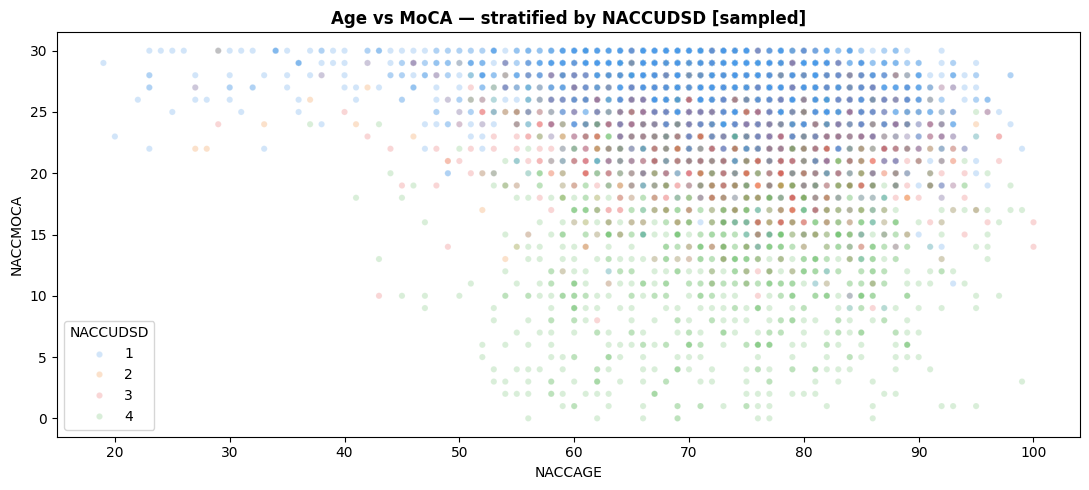

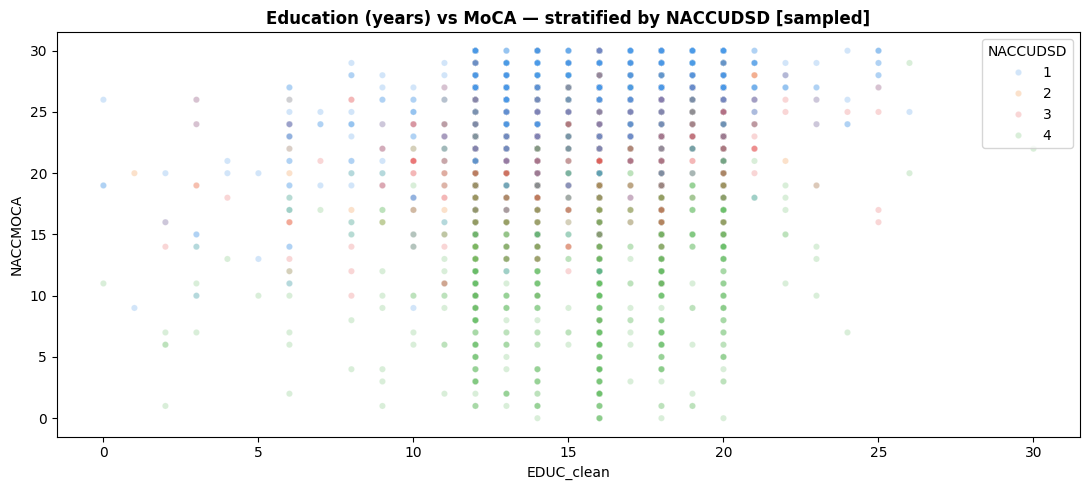

In [ ]:
# 11) SCATTER: AGE + EDUCATION vs MoCA (stratified by NACCUDSD)
palette = {1:"#4C9BE8", 2:"#F28B30", 3:"#E85C5C", 4:"#6ABF69"}

plot_sample = (
    df.dropna(subset=["NACCUDSD"])
    .sample(n=min(20000, len(df)), random_state=42)
)

for x_col, x_label in [("NACCAGE","Age"), ("EDUC_clean","Education (years)")]:
    if {x_col,"NACCMOCA"}.issubset(plot_sample.columns):
        plt.figure(figsize=(11, 5))
        sns.scatterplot(
            data=plot_sample.dropna(subset=[x_col,"NACCMOCA"]),
            x=x_col, y="NACCMOCA", hue="NACCUDSD",
            palette=palette, alpha=0.25, s=20
        )
        plt.title(f"{x_label} vs MoCA — stratified by NACCUDSD [sampled]", fontweight="bold")
        plt.tight_layout()
        plt.show()

Age vs MoCA stratified by NACCUDSD:
The blue dots (Normal, group 1) dominate the top of the chart across all ages, sitting mostly above MoCA 25. The green dots (Dementia, group 4) spread across the entire bottom half of the chart, with scores ranging from 0 all the way up to 25. The critical observation is that all four groups overlap heavily in the 60–85 age range — we cannot draw a horizontal or vertical line anywhere on this chart that cleanly separates the groups. Age alone is useless, and even combining age with MoCA still leaves a lot of overlap between groups 1, 2, and 3. Group 4 is the only one that visibly separates toward the bottom.

Education vs MoCA stratified by NACCUDSD:
The blue dots (Normal) cluster strongly in the upper portion regardless of education level. The green dots (Dementia) appear at every education level but spread downward — even highly educated patients (20+ years) appear with MoCA scores near zero. This directly shows that education delays but does not prevent dementia. The vertical striping pattern (because education is recorded in whole years) is normal. Again groups 1–3 overlap heavily, group 4 separates downward.


 TRANSITION MATRIX: First to Last Visit (row-normalized) 


last_udsd,1,2,3,4
first_udsd,,,,
1,0.765,0.037,0.123,0.075
2,0.313,0.265,0.243,0.179
3,0.120,0.045,0.428,0.408
4,0.005,0.005,0.020,0.970



 TRANSITION MATRIX: Adjacent Visits (row-normalized) 


NACCUDSD_next,1.0,2.0,3.0,4.0
NACCUDSD,,,,
1,0.915,0.024,0.054,0.007
2,0.241,0.504,0.200,0.055
3,0.101,0.043,0.675,0.181
4,0.004,0.005,0.018,0.973


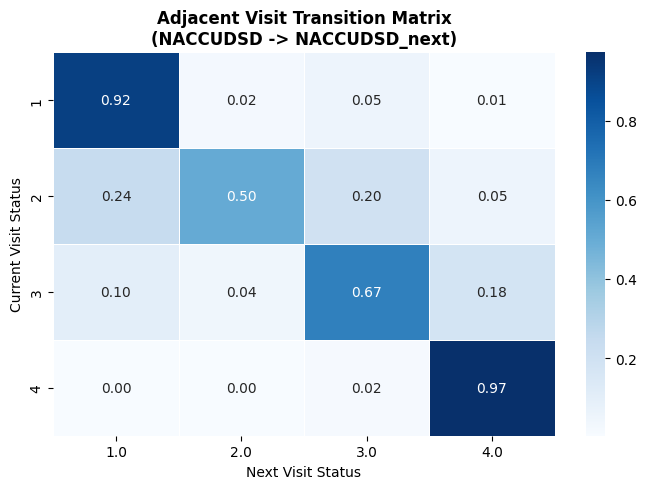

In [ ]:
# 12) TRANSITION MATRIX (DISEASE PROGRESSION)
t = df.dropna(subset=["NACCUDSD"]).sort_values(["NACCID","VISIT_ORDER"])
n_col = "NACCVNUM" if "NACCVNUM" in t.columns else "VISIT_ORDER"
n_agg = "nunique" if n_col == "NACCVNUM" else "max"

first_last = t.groupby("NACCID", observed=True).agg(
    first_udsd=("NACCUDSD", "first"),
    last_udsd=("NACCUDSD", "last"),
    n_visits=(n_col, n_agg)
)
first_last_2plus = first_last[first_last["n_visits"] >= 2]

print("\n TRANSITION MATRIX: First to Last Visit (row-normalized) ")
trans_fl = pd.crosstab(first_last_2plus["first_udsd"],
                       first_last_2plus["last_udsd"], normalize="index")
display(trans_fl.round(3))

# Adjacent visit transitions
tt = t[["NACCID","VISIT_ORDER","NACCUDSD"]].dropna().copy()
tt["NACCUDSD_next"] = tt.groupby("NACCID")["NACCUDSD"].shift(-1)
adj = tt.dropna(subset=["NACCUDSD_next"])

print("\n TRANSITION MATRIX: Adjacent Visits (row-normalized) ")
adj_trans = pd.crosstab(adj["NACCUDSD"], adj["NACCUDSD_next"], normalize="index")
display(adj_trans.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(adj_trans, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Adjacent Visit Transition Matrix\n(NACCUDSD -> NACCUDSD_next)", fontweight="bold")
plt.xlabel("Next Visit Status")
plt.ylabel("Current Visit Status")
plt.tight_layout()
plt.show()


Adjacent Visit Transition Matrix (what happens visit to visit):
Group 1 (Normal) — 92% stay Normal. Only 5% convert to MCI and 1% to Dementia between visits. Normal cognition is highly stable in this cohort.
Group 4 (Dementia) — 97% stay Dementia. Almost nobody reverses. Dementia is essentially a one-way door in this dataset, which is clinically expected.
Group 3 (MCI) — 67% stay MCI, 18% convert to Dementia, 10% revert to Normal. The 10% reversion is interesting — this could reflect genuine recovery, measurement variability, or reclassification by clinicians.
Group 2 (Impaired-not-MCI) — only 50% stay in group 2. This group is the most unstable — 24% revert to Normal and 20% progress to MCI. This confirms what we suspected earlier: group 2 is a transitional, poorly defined category that doesn't hold its shape over time.

First to Last Visit Transition Matrix:
Over the full observation period the patterns intensify. MCI patients (group 3) end up in Dementia 41% of the time by their last visit — much higher than the 18% adjacent rate, showing cumulative progression over years. Group 2 again shows the most movement, with 31% ending up back in Normal — further evidence this category is unstable.


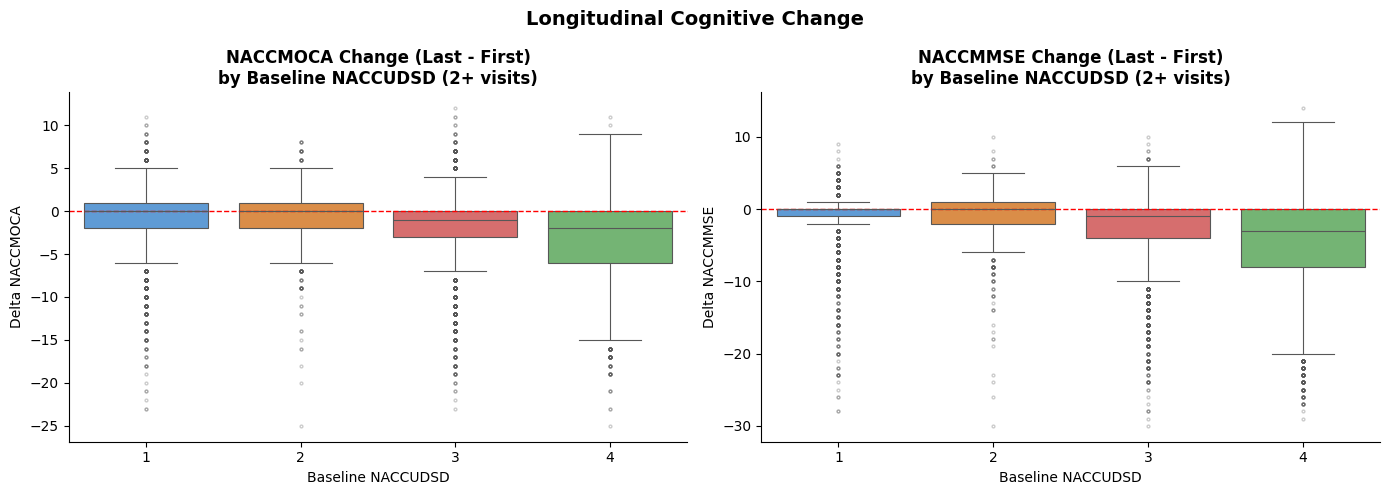

In [ ]:
# 13) LONGITUDINAL DELTA (Cognitive Change: Last - First)
def compute_delta(df_in, score_col, status_col="NACCUDSD"):
    d = df_in.dropna(subset=[status_col]).sort_values(["NACCID","VISIT_ORDER"])
    n_c = "NACCVNUM" if "NACCVNUM" in d.columns else "VISIT_ORDER"
    tmp = d.groupby("NACCID", observed=True).agg(
        status_first=(status_col, "first"),
        score_first=(score_col, "first"),
        score_last=(score_col, "last"),
        n_visits=(n_c, "nunique" if n_c == "NACCVNUM" else "max")
    )
    tmp = tmp[tmp["n_visits"] >= 2].dropna(subset=["score_first","score_last"])
    tmp["delta"] = tmp["score_last"] - tmp["score_first"]
    tmp["status_first"] = tmp["status_first"].astype(int).astype(str)  # fix key type
    return tmp.reset_index()

pal_str = {"1":"#4C9BE8", "2":"#F28B30", "3":"#E85C5C", "4":"#6ABF69"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, score in zip(axes, ["NACCMOCA", "NACCMMSE"]):
    if score not in df.columns:
        continue
    delta_df = compute_delta(df, score)
    sns.boxplot(
        data=delta_df, x="status_first", y="delta",
        hue="status_first",
        order=["1","2","3","4"],
        palette=pal_str,
        ax=ax, linewidth=0.8, legend=False,
        flierprops=dict(marker="o", markersize=2, alpha=0.3)
    )
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{score} Change (Last - First)\nby Baseline NACCUDSD (2+ visits)",
                 fontweight="bold")
    ax.set_xlabel("Baseline NACCUDSD")
    ax.set_ylabel(f"Delta {score}")
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Longitudinal Cognitive Change", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The red dashed line at zero is the key reference — above it means cognitive improvement, below means decline.
Group 1 (Normal) — median sits right at zero. Normal patients on average neither improve nor decline over time, which makes sense. But the box stretches both above and below zero showing real variability — some normals improve slightly, some decline slightly.
Group 2 (Impaired-not-MCI) — median also near zero but with a wider spread downward. Confirms the instability we saw in the transition matrix — this group goes both ways.
Group 3 (MCI) — median clearly below zero for both MoCA and MMSE. MCI patients are declining on average over their observation period. The box is mostly below the red line, with a longer tail downward — some MCI patients decline dramatically.
Group 4 (Dementia) — median furthest below zero, box entirely below the red line. Dementia patients show the most consistent and steepest decline. The whiskers extend down to -20 for MoCA and -30 for MMSE — these are patients who started at moderate scores and ended near zero.

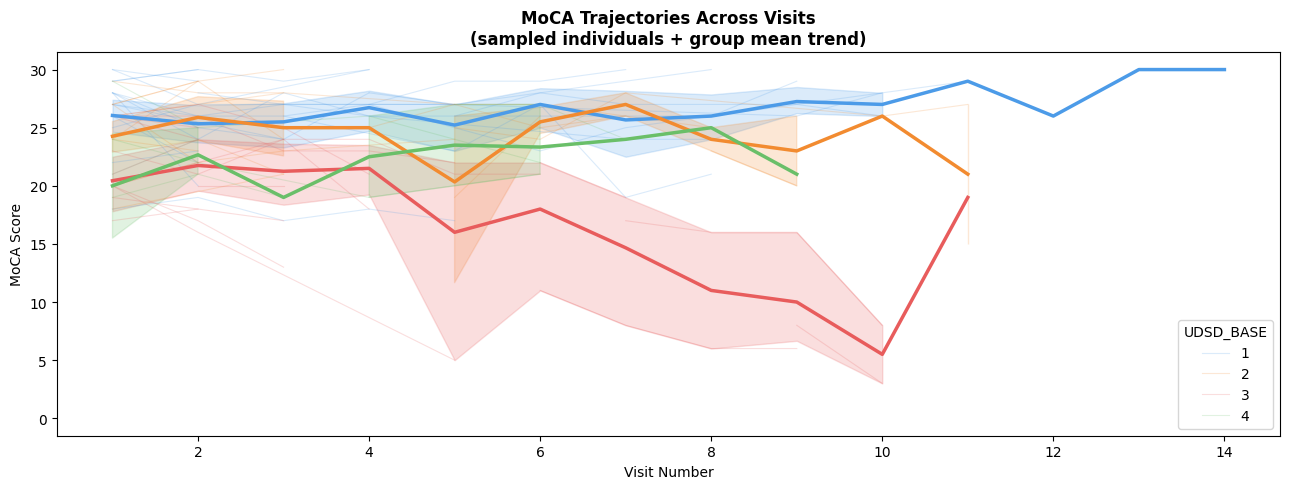

In [ ]:
# 14) SAMPLE TRAJECTORIES (MoCA over visits)
if {"NACCID","VISIT_ORDER","NACCMOCA","NACCUDSD"}.issubset(df.columns):
    base2 = df.dropna(subset=["NACCUDSD"]).sort_values(["NACCID","VISIT_ORDER"]).copy()
    base_status = base2.groupby("NACCID")["NACCUDSD"].first()
    base2 = base2.join(base_status.rename("UDSD_BASE"), on="NACCID")

    N = 40
    sampled_ids = (
        base2[["NACCID","UDSD_BASE"]].drop_duplicates()
        .groupby("UDSD_BASE", observed=True)
        .apply(lambda g: g.sample(n=min(N, len(g)), random_state=42))["NACCID"]
        .values
    )
    traj = base2[base2["NACCID"].isin(sampled_ids)].dropna(subset=["NACCMOCA"])

    plt.figure(figsize=(13, 5))
    sns.lineplot(data=traj, x="VISIT_ORDER", y="NACCMOCA",
                 hue="UDSD_BASE", units="NACCID",
                 estimator=None, alpha=0.2, palette=palette, linewidth=0.8)
    sns.lineplot(data=traj, x="VISIT_ORDER", y="NACCMOCA",
                 hue="UDSD_BASE", palette=palette, linewidth=2.5, legend=False)
    plt.title("MoCA Trajectories Across Visits\n(sampled individuals + group mean trend)",
              fontweight="bold")
    plt.xlabel("Visit Number")
    plt.ylabel("MoCA Score")
    plt.tight_layout()
    plt.show()



Group 1 (Blue — Normal) — flat line hovering around 27–30 across all visits. Completely stable over time. The individual trajectories (faint lines) barely deviate from the group mean.
Group 2 (Orange — Impaired-not-MCI) — starts around 25, stays relatively stable but with more wobble than Normal. Consistent with what we've seen — this group is uncertain and variable.
Group 3 (Green — MCI) — starts around 22, stays relatively flat through visits 1–8, then starts drifting downward in later visits. MCI patients hold steady for years before declining — this is clinically meaningful and suggests a window for intervention.
Group 4 (Red — Dementia) — this is the standout. Starts around 20, then drops steeply and continuously visit after visit, reaching near zero by visit 10–11. The pink shaded band widens dramatically as visits progress, meaning dementia patients diverge from each other over time — some decline faster than others. This is the heterogeneity within dementia we've been seeing throughout the EDA.

The single most important insight from this chart: The four groups don't just differ in where they start — they differ fundamentally in their shape of trajectory over time. Normal is flat, MCI is slow then declining, Dementia is steep and continuous.

In [ ]:
# 15) PERSON-LEVEL SUMMARY DATASET
df = df.sort_values(["NACCID","VISIT_ORDER"])

agg_dict = {}
for col, aggs in [
    ("NACCAGE",    ["first","last","mean"]),
    ("EDUC_clean", ["first"]),
    ("SEX",        ["first"]),
    ("RACE",       ["first"]),
    ("HISPANIC",   ["first"]),
    ("NACCUDSD",   ["first","last"]),
    ("NACCMOCA",   ["first","last","mean","min"]),
    ("NACCMMSE",   ["first","last","mean","min"]),
    ("NACCAPOE",   ["first"]),
    ("NACCNE4S",   ["first"]),
    ("NACCVNUM",   ["nunique"]),
    ("DEPDSEV",    ["first"]),
    ("ANXSEV",     ["first"]),
    ("APASEV",     ["first"]),
    ("AGITSEV",    ["first"]),
]:
    if col in df.columns:
        agg_dict[col] = aggs

person_df = df.groupby("NACCID", observed=True).agg(agg_dict)
person_df.columns = [f"{a}_{b}" for a, b in person_df.columns]
person_df = person_df.rename(columns={"NACCVNUM_nunique": "n_visits"}).reset_index()

print(f"\nPerson-level dataset: {person_df.shape[0]:,} participants")
display(person_df.head())
display(person_df.describe(include="all"))

print("\nEDA Complete - ready for Phase 3 (Clustering + Modeling)")


Person-level dataset: 55,268 participants


,NACCID,NACCAGE_first,NACCAGE_last,NACCAGE_mean,EDUC_clean_first,SEX_first,RACE_first,HISPANIC_first,NACCUDSD_first,NACCUDSD_last,...,NACCMMSE_last,NACCMMSE_mean,NACCMMSE_min,NACCAPOE_first,NACCNE4S_first,n_visits,DEPDSEV_first,ANXSEV_first,APASEV_first,AGITSEV_first
0,NACC000011,62,65,63.500000,16.0,2,1,0,3,2,...,28.0,29.250000,28.0,1.0,0.0,4,8.0,1.0,8.0,8.0
1,NACC000034,79,86,82.857143,15.0,2,1,0,3,4,...,NaN,NaN,NaN,4.0,2.0,7,8.0,8.0,1.0,8.0
2,NACC000067,60,62,61.000000,18.0,1,1,0,3,3,...,29.0,28.666667,28.0,1.0,0.0,3,2.0,2.0,8.0,1.0
3,NACC000073,44,44,44.000000,18.0,2,1,0,1,1,...,NaN,NaN,NaN,NaN,NaN,1,8.0,8.0,8.0,1.0
4,NACC000095,87,87,87.000000,16.0,1,1,0,4,4,...,19.0,19.000000,19.0,2.0,1.0,1,8.0,3.0,8.0,2.0


,NACCID,NACCAGE_first,NACCAGE_last,NACCAGE_mean,EDUC_clean_first,SEX_first,RACE_first,HISPANIC_first,NACCUDSD_first,NACCUDSD_last,...,NACCMMSE_last,NACCMMSE_mean,NACCMMSE_min,NACCAPOE_first,NACCNE4S_first,n_visits,DEPDSEV_first,ANXSEV_first,APASEV_first,AGITSEV_first
count,55268,55268.000000,55268.000000,55268.000000,54867.000000,55268.000000,55268.000000,55268.000000,55268.000000,55268.000000,...,31790.000000,31790.000000,31790.000000,40946.000000,40946.000000,55268.000000,53292.000000,53303.000000,53301.000000,53331.000000
unique,55268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NACC000184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,71.020699,74.389737,72.689230,15.254433,1.574763,2.846294,0.134834,2.443095,2.619780,...,23.370305,24.323312,22.866247,1.819006,0.474332,3.753601,6.173741,6.373675,6.566106,6.790366
std,NaN,10.386234,10.995620,10.496859,3.393000,0.494383,10.383100,0.660177,1.305894,1.333114,...,7.612689,6.549920,7.440913,1.061518,0.619493,3.352593,2.961857,2.833785,2.687070,2.545621
min,NaN,18.000000,18.000000,18.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,NaN,65.000000,68.000000,66.500000,13.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,20.000000,21.666667,20.000000,1.000000,0.000000,1.000000,2.000000,3.000000,8.000000,8.000000
50%,NaN,72.000000,75.000000,73.428571,16.000000,2.000000,1.000000,0.000000,3.000000,3.000000,...,27.000000,27.000000,26.000000,2.000000,0.000000,3.000000,8.000000,8.000000,8.000000,8.000000
75%,NaN,78.000000,82.000000,80.000000,18.000000,2.000000,1.000000,0.000000,4.000000,4.000000,...,29.000000,29.000000,28.000000,2.000000,1.000000,5.000000,8.000000,8.000000,8.000000,8.000000



EDA Complete - ready for Phase 3 (Clustering + Modeling)


55,268 unique participants.

MoCA has count 28,341 and MMSE has 31,790 out of 55,268 participants — meaning roughly half of people have usable cognitive scores at the person level. This is the missingness problem we identified earlier now showing up at the modeling level. We'll need an imputation strategy before fitting any model.
n_visits ranges from 1 to 20, median around 3–4 visits per person. The 75th percentile is 5 visits, meaning most participants have a reasonable longitudinal record.
NACCAPOE has 40,946 non-null — better than expected, about 74% coverage. That's workable for including genetic data in modeling.
Age range is 18–110 with mean around 71–74 — the dataset spans a very wide age range but is concentrated in older adults as expected.

Summary:
The dataset has 55,268 participants across four cognitive status groups with a clear class imbalance favoring Normal patients. MoCA and MMSE are the strongest predictors but are missing in roughly half the data. Behavioral symptoms are noisy but APASEV carries more signal than expected. Age does not discriminate between groups. Education has a modest protective effect. Group 2 is unstable and may need to be merged. Dementia is a one-way door with a steep declining trajectory that separates it clearly from the other three groups.

Target variable (NACCUDSD):

It has a class imbalance problem, Group 2 is unstable, Dementia is essentially irreversible, and the four groups have fundamentally different longitudinal trajectories. The transition matrices, delta plots, and trajectory chart all directly characterize the target variable in depth.

Distributions at every level:

Overall histograms for MoCA and MMSE, boxplots and violin plots for every feature broken down by target group, demographic breakdowns by target group, missingness patterns by target group, and person-level summary statistics. Every major variable has been examined.

What's driving the model:

NACCMOCA : correlation -0.71 with target, clearest separation in violin plots

NACCMMSE : correlation -0.65, consistent decline across groups

APASEV : stronger than expected at -0.44, worth keeping

DEPDSEV, ANXSEV, AGITSEV : moderate signal, noisy but consistent

EDUC_clean : weak but real, cognitive reserve effect confirmed

NACCNE4S / NACCAPOE : genetic risk factor, 74% coverage

NACCAGE : weakest, nearly flat across groups

In [ ]:
# STEP 1: FEATURE ENGINEERING
from sklearn.preprocessing import LabelEncoder

# person_df
# Making a clean modeling copy
model_df = person_df.copy()

# 1A. Merging Group 2 into Group 3 (Impaired → MCI)
# Group 2 is only 4% of data and highly unstable (transition matrix showed 50% stay rate)
model_df["NACCUDSD_first"] = model_df["NACCUDSD_first"].replace(2, 3)
model_df["NACCUDSD_last"]  = model_df["NACCUDSD_last"].replace(2, 3)

Merging Group 2
Copies the person-level dataset and merges the "Impaired-not-MCI" category (Group 2) into MCI (Group 3) because Group 2 was only 4% of the data and the transition matrix showed it was too unstable to model reliably on its own.

In [ ]:
# 1B. Defining target (FIRST visit diagnosis = baseline status)
model_df["TARGET"] = model_df["NACCUDSD_first"].astype(int)

# Checking class distribution after merge
print("TARGET distribution after merging Group 2 into Group 3:")
print(model_df["TARGET"].value_counts().sort_index())
print(f"\nClass proportions:")
print(model_df["TARGET"].value_counts(normalize=True).sort_index().round(3))


TARGET distribution after merging Group 2 into Group 3:
TARGET
1    22863
3    14962
4    17443
Name: count, dtype: int64

Class proportions:
TARGET
1    0.414
3    0.271
4    0.316
Name: proportion, dtype: float64


Sets each patient's first visit diagnosis as the prediction target, giving us 3 classes: Normal 22,863 (41%), MCI 14,962 (27%), Dementia 17,443 (32%). The class imbalance visible here is addressed later with SMOTENC.


In [ ]:
# 1C. Binarizing behavioral symptoms
for col in ["DEPDSEV_first","ANXSEV_first","APASEV_first","AGITSEV_first"]:
    base = col.replace("_first","")
    if col in model_df.columns:
        new_col = base + "_present"
        model_df[new_col] = (model_df[col] > 1).astype(float)
        model_df[new_col] = model_df[new_col].where(model_df[col].notna(), np.nan)
        print(f"{new_col} — present rate: {model_df[new_col].mean():.2%}")
    else:
        print(f" {col} NOT FOUND in model_df — behavioral features missing")

# Check what behavioral cols actually exist
behav_present = [c for c in model_df.columns if any(
    x in c for x in ['DEP','ANX','APA','AGIT'])]
print(f"\nBehavioral columns found: {behav_present}")

DEPDSEV_present — present rate: 82.39%
ANXSEV_present — present rate: 85.39%
APASEV_present — present rate: 88.29%
AGITSEV_present — present rate: 89.06%

Behavioral columns found: ['DEPDSEV_first', 'ANXSEV_first', 'APASEV_first', 'AGITSEV_first', 'DEPDSEV_present', 'ANXSEV_present', 'APASEV_present', 'AGITSEV_present']


Converts depression, anxiety, apathy and agitation severity scores into simple yes/no flags, where 0 means absent and 1 means present. All four columns were found successfully. Present rates are high across the board: depression 82%, anxiety 85%, apathy 88%, agitation 89%, which makes sense given this is a clinical population.

In [ ]:
# 1D. Cognitive slope (rate of change per visit)
# Captures trajectory shape, our EDA showed groups differ in slope not just level
if all(c in model_df.columns for c in ["NACCMOCA_first","NACCMOCA_last","n_visits"]):
    model_df["MOCA_slope"] = (
        (model_df["NACCMOCA_last"] - model_df["NACCMOCA_first"]) /
        model_df["n_visits"].clip(lower=1)
    )
    print(f"\nMOCA_slope created — mean: {model_df['MOCA_slope'].mean():.2f}")

if all(c in model_df.columns for c in ["NACCMMSE_first","NACCMMSE_last","n_visits"]):
    model_df["MMSE_slope"] = (
        (model_df["NACCMMSE_last"] - model_df["NACCMMSE_first"]) /
        model_df["n_visits"].clip(lower=1)
    )
    print(f"MMSE_slope created — mean: {model_df['MMSE_slope'].mean():.2f}")



MOCA_slope created — mean: -0.19
MMSE_slope created — mean: -0.42


Creates two new features capturing how fast each patient's scores changed (last score minus first score) divided by number of visits. MOCA slope averages −0.19 and MMSE slope averages −0.42 per visit, both negative as expected since patients decline on average.

In [ ]:
# 1E. Define final feature set
feature_cols = [c for c in [
    # Cognitive scores (strongest signal)
    "NACCMOCA_first", "NACCMMSE_first",
    "MOCA_slope", "MMSE_slope",
    # Demographics
    "NACCAGE_first", "EDUC_clean_first", "SEX_first",
    # Behavioral (binarized)
    "DEP_present", "ANX_present", "APA_present", "AGIT_present",
    # Genetic
    "NACCNE4S_first",
    # Visit count
    "n_visits",
] if c in model_df.columns]

# raw behavioral cols if binarized ones weren't created
for raw in ["DEPDSEV_first","ANXSEV_first","APASEV_first","AGITSEV_first"]:
    if raw in model_df.columns and raw not in feature_cols:
        feature_cols.append(raw)

print(f"\nFinal feature set ({len(feature_cols)} features):")
print(feature_cols)


Final feature set (13 features):
['NACCMOCA_first', 'NACCMMSE_first', 'MOCA_slope', 'MMSE_slope', 'NACCAGE_first', 'EDUC_clean_first', 'SEX_first', 'NACCNE4S_first', 'n_visits', 'DEPDSEV_first', 'ANXSEV_first', 'APASEV_first', 'AGITSEV_first']


Locks in 13 features for all models: MoCA first visit, MMSE first visit, MoCA slope, MMSE slope, age, education, sex, APOE genetic marker, number of visits, and all four behavioral severity scores. Up from 9 features after the behavioral fix.

In [ ]:
# STEP 2: SPLIT + IMPUTE
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Dropping rows where target is missing
model_df_clean = model_df.dropna(subset=["TARGET"]).copy()
model_df_clean["TARGET"] = model_df_clean["TARGET"].astype(int)

X = model_df_clean[feature_cols].copy()
y = model_df_clean["TARGET"].copy()

print(f"Dataset shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

# Stratified split (preserves class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

# Imputing missing values (median strategy, robust to outliers)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feature_cols)

# Scaling features (required for LR, KNN, Naive Bayes)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_imp),      columns=feature_cols)

# Keeping unscaled version too (for tree-based models, they don't need scaling)
X_train_raw = X_train_imp.copy()
X_test_raw  = X_test_imp.copy()

print("\n Split + imputation + scaling complete")
print(f"Missing values remaining in X_train_raw: {X_train_raw.isna().sum().sum()}")

Dataset shape: (55268, 13)
Target distribution:
TARGET
1    22863
3    14962
4    17443
Name: count, dtype: int64

Train: 44,214 | Test: 11,054

 Split + imputation + scaling complete
Missing values remaining in X_train_raw: 0


Splits 55,268 patients 80/20 into 44,214 train and 11,054 test using stratified split to preserve class proportions. Fills missing values with column medians and scales features to mean 0 standard deviation 1. Zero missing values remain after imputation.


In [ ]:
# STEP 2B: SMOTENC — Class Imbalance Handling
# SMOTENC handles mixed continuous + categorical features

from imblearn.over_sampling import SMOTENC

print("Class distribution BEFORE SMOTENC:")
print(y_train.value_counts().sort_index())
print(f"\nClass proportions:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

# Identifying which feature columns are categorical
# These need special treatment in SMOTENC
cat_feature_names = [
    "SEX_first", "NACCNE4S_first",
    "DEPDSEV_first", "ANXSEV_first", "APASEV_first", "AGITSEV_first"
]

# Getting indices of categorical columns in feature_cols list
cat_indices = [i for i, col in enumerate(feature_cols)
               if col in cat_feature_names]
print(f"\nCategorical feature indices for SMOTENC: {cat_indices}")
print(f"Categorical features: {[feature_cols[i] for i in cat_indices]}")

# Applying SMOTENC on the RAW (unscaled) training data
# fitting SMOTENC before scaling, on imputed data
smote = SMOTENC(
    categorical_features=cat_indices,
    random_state=42,
    k_neighbors=5
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train)
X_train_sm = pd.DataFrame(X_train_sm, columns=feature_cols)
y_train_sm = pd.Series(y_train_sm, name="TARGET")

print("\nClass distribution AFTER SMOTENC:")
print(y_train_sm.value_counts().sort_index())
print(f"\nClass proportions (should be balanced now):")
print(y_train_sm.value_counts(normalize=True).sort_index().round(3))
print(f"\nTraining set size: {len(X_train_raw):,} → {len(X_train_sm):,} after oversampling")

# Scaling the SMOTE-resampled data for models that need it
from sklearn.preprocessing import StandardScaler
scaler_sm = StandardScaler()
X_train_sm_scaled = pd.DataFrame(
    scaler_sm.fit_transform(X_train_sm),
    columns=feature_cols
)
# Testing set stays the same
X_test_sm_scaled = pd.DataFrame(
    scaler_sm.transform(X_test_raw),
    columns=feature_cols
)

print("\nSMOTENC complete — use X_train_sm / X_train_sm_scaled for multiclass models")
print("X_test_raw and X_test_scaled remain unchanged")

Class distribution BEFORE SMOTENC:
TARGET
1    18290
3    11970
4    13954
Name: count, dtype: int64

Class proportions:
TARGET
1    0.414
3    0.271
4    0.316
Name: proportion, dtype: float64

Categorical feature indices for SMOTENC: [6, 7, 9, 10, 11, 12]
Categorical features: ['SEX_first', 'NACCNE4S_first', 'DEPDSEV_first', 'ANXSEV_first', 'APASEV_first', 'AGITSEV_first']

Class distribution AFTER SMOTENC:
TARGET
1    18290
3    18290
4    18290
Name: count, dtype: int64

Class proportions (should be balanced now):
TARGET
1    0.333
3    0.333
4    0.333
Name: proportion, dtype: float64

Training set size: 44,214 → 54,870 after oversampling

SMOTENC complete — use X_train_sm / X_train_sm_scaled for multiclass models
X_test_raw and X_test_scaled remain unchanged


Addresses the professor's feedback on class imbalance. Before: Normal 18,290, MCI 11,970, Dementia 13,954. After: all three classes exactly 18,290. Training set grows from 44,214 to 54,870. Six features are correctly treated as categorical : sex, APOE genetic marker, and all four behavioral flags. So synthetic patients get valid discrete values rather than interpolated decimals.

MODEL 1 — PCA
Variance explained by PC1: 17.13%
Variance explained by PC2: 10.21%
Total variance (PC1+PC2):  27.34%


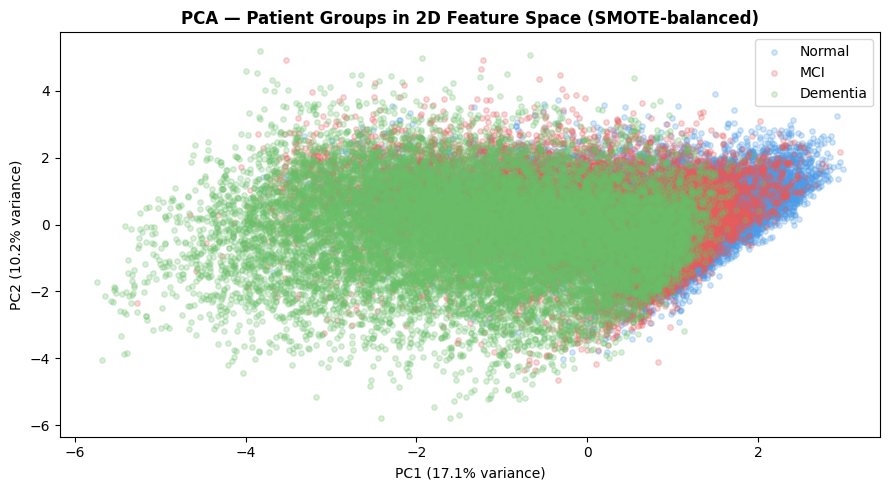


MODEL 2 — K-MEDOIDS (k=3)
Using K-Medoids — robust to skewed distributions (professor's recommendation)
Manual PAM implementation — avoids NumPy 2.0 compatibility issues

Computing pairwise distances for K-Medoids...
  Converged at iteration 4

Adjusted Rand Index (vs true labels): 0.036
(1.0 = perfect match, 0.0 = random)

Cluster composition — what true labels ended up in each cluster:
True Label (1=Normal, 3=MCI, 4=Dementia)      1      3      4
K-Medoids Cluster                                            
0                                         0.067  0.261  0.672
1                                         0.367  0.379  0.254
2                                         0.401  0.325  0.274


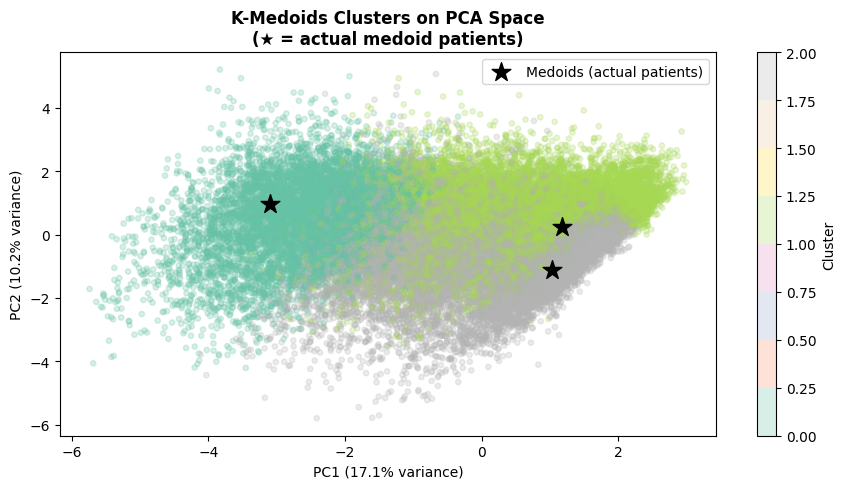

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, pairwise_distances
import numpy as np

# MODEL 1: PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_sm_scaled)

print("MODEL 1 — PCA")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance (PC1+PC2):  {pca.explained_variance_ratio_.sum():.2%}")

# Plotting PCA colored by true label
plt.figure(figsize=(9,5))
palette_pca = {1:"#4C9BE8", 3:"#E85C5C", 4:"#6ABF69"}
for label, color in palette_pca.items():
    mask = y_train_sm.values == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, alpha=0.25, s=15,
                label={1:"Normal", 3:"MCI", 4:"Dementia"}[label])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA — Patient Groups in 2D Feature Space (SMOTE-balanced)", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# MODEL 2: K-MEDOIDS (manual implementation using PAM algorithm)
class KMedoids:
    """
    K-Medoids clustering using PAM (Partitioning Around Medoids).
    More robust than K-Means for skewed distributions — uses actual
    data points as cluster centers instead of means.
    Professor's recommendation for skewed cognitive score distributions.
    """
    def __init__(self, n_clusters=3, max_iter=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.medoid_indices_ = None
        self.labels_ = None

    def fit_predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        np.random.seed(self.random_state)
        n = len(X)

        # Using a sample for speed on large datasets
        sample_size = min(2000, n)
        sample_idx = np.random.choice(n, sample_size, replace=False)
        X_sample = X[sample_idx]

        # Computing pairwise distances on sample
        print("Computing pairwise distances for K-Medoids...")
        D = pairwise_distances(X_sample, metric="euclidean")

        # Initializing medoids randomly
        med_pos = np.random.choice(sample_size, self.n_clusters, replace=False)

        for iteration in range(self.max_iter):
            # Assigning each point to nearest medoid
            labels = np.argmin(D[:, med_pos], axis=1)

            # finding point in each cluster that minimizes
            # total distance to all other points in the cluster
            new_med_pos = med_pos.copy()
            for k in range(self.n_clusters):
                cluster_mask = labels == k
                if cluster_mask.sum() == 0:
                    continue
                cluster_indices = np.where(cluster_mask)[0]
                # Cost = sum of distances to all other cluster members
                sub_D = D[np.ix_(cluster_indices, cluster_indices)]
                best_local = np.argmin(sub_D.sum(axis=1))
                new_med_pos[k] = cluster_indices[best_local]

            if np.all(new_med_pos == med_pos):
                print(f"  Converged at iteration {iteration + 1}")
                break
            med_pos = new_med_pos

        # Storinging medoid indices (mapped back to original dataset)
        self.medoid_indices_ = sample_idx[med_pos]

        # Assigning ALL training points to nearest medoid
        medoid_vectors = X[self.medoid_indices_]
        full_D = pairwise_distances(X, medoid_vectors, metric="euclidean")
        self.labels_ = np.argmin(full_D, axis=1)
        return self.labels_

print("\nMODEL 2 — K-MEDOIDS (k=3)")
print("Using K-Medoids — robust to skewed distributions (professor's recommendation)")
print("Manual PAM implementation — avoids NumPy 2.0 compatibility issues\n")

X_train_arr = X_train_sm_scaled.values

kmed = KMedoids(n_clusters=3, random_state=42)
kmed_labels = kmed.fit_predict(X_train_arr)

# Comparing K-Medoids clusters to true labels
ari = adjusted_rand_score(y_train_sm, kmed_labels)
print(f"\nAdjusted Rand Index (vs true labels): {ari:.3f}")
print("(1.0 = perfect match, 0.0 = random)")

# Cluster composition table
kmed_df = pd.DataFrame({
    "cluster": kmed_labels,
    "true_label": y_train_sm.values
})
print("\nCluster composition — what true labels ended up in each cluster:")
comp = pd.crosstab(kmed_df["cluster"], kmed_df["true_label"],
                   colnames=["True Label (1=Normal, 3=MCI, 4=Dementia)"],
                   rownames=["K-Medoids Cluster"],
                   normalize="index").round(3)
print(comp)

# Plotting K-Medoids clusters on PCA axes
plt.figure(figsize=(9,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],
                      c=kmed_labels, cmap="Set2", alpha=0.25, s=15)

# Marking the actual medoid patients
medoid_scaled = X_train_arr[kmed.medoid_indices_]
medoid_pca = pca.transform(
    pd.DataFrame(medoid_scaled, columns=feature_cols)
)
plt.scatter(medoid_pca[:,0], medoid_pca[:,1],
            c="black", s=200, marker="*", zorder=5, label="Medoids (actual patients)")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("K-Medoids Clusters on PCA Space\n(★ = actual medoid patients)",
          fontweight="bold")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()

PCA compresses 13 features into 2 dimensions capturing only 27.34% of total variance. The low number confirms groups do not cleanly separate in 2D, which is consistent with the overlapping distributions seen in EDA. K-Medoids converged at iteration 4 and was used instead of K-Means because cognitive score distributions are skewed. K-Medoids uses actual patient data points as cluster centers rather than means, making it more robust to outliers.

In [ ]:
# MODELS 3–7: SUPERVISED (SIMPLE) WITH SMOTENC
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings("ignore")

results = {}

def evaluate(name, model, X_tr, X_te, y_tr, y_te, class_names=None):
    model.fit(X_tr, y_tr)

    # Training performance
    y_train_pred = model.predict(X_tr)
    train_acc = accuracy_score(y_tr, y_train_pred)

    # Test performance
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    results[name] = acc

    gap = train_acc - acc
    overfit_flag = " <-- possible overfit" if gap > 0.1 else " OK"

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  TRAIN Accuracy: {train_acc:.4f}")
    print(f"  TEST  Accuracy: {acc:.4f}")
    print(f"  Gap:            {gap:.4f}{overfit_flag}")
    print(f"{'='*55}")

    if class_names is None:
        unique = sorted(y_te.unique())
        label_map = {1:"Normal", 3:"MCI", 4:"Dementia"}
        class_names = [label_map.get(c, str(c)) for c in unique]

    print("TRAIN classification report:")
    print(classification_report(y_tr, y_train_pred,
          target_names=class_names, zero_division=0))
    print("TEST classification report:")
    print(classification_report(y_te, y_pred,
          target_names=class_names, zero_division=0))
    return model

X_train_scaled = X_train_scaled.reset_index(drop=True)
X_test_scaled  = X_test_scaled.reset_index(drop=True)
X_train_raw    = X_train_raw.reset_index(drop=True)
X_test_raw     = X_test_raw.reset_index(drop=True)
X_train_sm     = X_train_sm.reset_index(drop=True)
X_train_sm_scaled = X_train_sm_scaled.reset_index(drop=True)
X_test_sm_scaled  = X_test_sm_scaled.reset_index(drop=True)
y_train        = y_train.reset_index(drop=True)
y_test         = y_test.reset_index(drop=True)
y_train_sm     = y_train_sm.reset_index(drop=True)

print("All indices reset")
print(f"X_train_scaled: {X_train_scaled.shape} | y_train: {y_train.shape}")
print(f"X_train_sm:     {X_train_sm.shape}     | y_train_sm: {y_train_sm.shape}")
print(f"X_test_raw:     {X_test_raw.shape}      | y_test: {y_test.shape}")

# MODEL 3 — Dummy Baseline
m3 = evaluate("MODEL 3: Dummy Baseline",
    DummyClassifier(strategy="most_frequent", random_state=42),
    X_train_scaled, X_test_scaled, y_train, y_test)

# MODEL 4 — Logistic Regression Binomial (Normal vs Dementia only)
mask_bin      = y_train.isin([1, 4])
mask_bin_test = y_test.isin([1, 4])
m4 = evaluate("MODEL 4: Logistic Regression (Binomial)",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_scaled[mask_bin],      X_test_scaled[mask_bin_test],
    y_train[mask_bin],             y_test[mask_bin_test],
    class_names=["Normal", "Dementia"])

# MODEL 5 — Logistic Regression Multinomial WITH SMOTENC
m5 = evaluate("MODEL 5: Logistic Regression (Multinomial + SMOTENC)",
    LogisticRegression(multi_class="multinomial", max_iter=1000, random_state=42),
    X_train_sm_scaled, X_test_sm_scaled, y_train_sm, y_test)

# MODEL 6 — Decision Tree WITH SMOTENC
m6 = evaluate("MODEL 6: Decision Tree (+ SMOTENC)",
    DecisionTreeClassifier(max_depth=6, random_state=42),
    X_train_sm, X_test_raw, y_train_sm, y_test)

# MODEL 7 — Naive Bayes WITH SMOTENC
m7 = evaluate("MODEL 7: Naive Bayes (+ SMOTENC)",
    GaussianNB(),
    X_train_sm_scaled, X_test_sm_scaled, y_train_sm, y_test)

# Summary so far
print("\n\nACCURACY SUMMARY (Models 3–7)")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 40)
    print(f"{name[:52]:<52} {acc:.4f}  {bar}")

All indices reset
X_train_scaled: (44214, 13) | y_train: (44214,)
X_train_sm:     (54870, 13)     | y_train_sm: (54870,)
X_test_raw:     (11054, 13)      | y_test: (11054,)

  MODEL 3: Dummy Baseline
  TRAIN Accuracy: 0.4137
  TEST  Accuracy: 0.4137
  Gap:            -0.0000 OK
TRAIN classification report:
              precision    recall  f1-score   support

      Normal       0.41      1.00      0.59     18290
         MCI       0.00      0.00      0.00     11970
    Dementia       0.00      0.00      0.00     13954

    accuracy                           0.41     44214
   macro avg       0.14      0.33      0.20     44214
weighted avg       0.17      0.41      0.24     44214

TEST classification report:
              precision    recall  f1-score   support

      Normal       0.41      1.00      0.59      4573
         MCI       0.00      0.00      0.00      2992
    Dementia       0.00      0.00      0.00      3489

    accuracy                           0.41     11054
   macro av

Model 3 — Dummy Baseline (41.4%): Predicts Normal for every patient, zero recall for MCI and Dementia. This is the performance floor every real model must beat.

Model 4 — Logistic Binomial (92.4%): Trained only on Normal vs Dementia, the two most distinct groups. Normal recall 95%, Dementia recall 89%. No class balancing needed here since it is a binary problem with two reasonably sized groups.

Model 5 — Logistic Multinomial (69.8%): Adds MCI as a third class with SMOTE-balanced training. MCI recall 52%, showing that balancing classes meaningfully helps the model find MCI patients.

Model 6 — Decision Tree (67.4%): Non-linear splits help slightly but the model does not outperform logistic regression. MCI recall 43%.

Model 7 — Naive Bayes (65.8%): Weakest supervised model because its feature independence assumption is violated. MoCA and MMSE are correlated with each other, which Naive Bayes cannot handle well. MCI recall only 36%.

In [ ]:
# MODELS 8 & 9: COMPLEX MODELS WITH SMOTENC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# MODEL 8 — Random Forest
m8 = evaluate("MODEL 8: Random Forest (+ SMOTENC)",
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    X_train_sm, X_test_raw, y_train_sm, y_test)

# MODEL 9 — Gradient Boosting
m9 = evaluate("MODEL 9: Gradient Boosting (+ SMOTENC)",
    GradientBoostingClassifier(n_estimators=200, max_depth=5,
                               learning_rate=0.05, random_state=42),
    X_train_sm, X_test_raw, y_train_sm, y_test)

# Summary including Models 8 and 9
print("\nACCURACY SUMMARY (Models 3–9)")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 40)
    print(f"{name[:52]:<52} {acc:.4f}  {bar}")


  MODEL 8: Random Forest (+ SMOTENC)
  TRAIN Accuracy: 0.7345
  TEST  Accuracy: 0.6998
  Gap:            0.0347 OK
TRAIN classification report:
              precision    recall  f1-score   support

      Normal       0.78      0.74      0.76     18290
         MCI       0.61      0.66      0.63     18290
    Dementia       0.83      0.80      0.82     18290

    accuracy                           0.73     54870
   macro avg       0.74      0.73      0.74     54870
weighted avg       0.74      0.73      0.74     54870

TEST classification report:
              precision    recall  f1-score   support

      Normal       0.81      0.72      0.76      4573
         MCI       0.47      0.55      0.51      2992
    Dementia       0.80      0.80      0.80      3489

    accuracy                           0.70     11054
   macro avg       0.69      0.69      0.69     11054
weighted avg       0.72      0.70      0.71     11054


  MODEL 9: Gradient Boosting (+ SMOTENC)
  TRAIN Accuracy: 0.755

Model 8 — Random Forest (70.0%): MCI recall 55%, the highest of models 3 through 7. The forest finds non-linear feature combinations that help identify MCI specifically. Dementia recall 80%, Normal recall 72%.

Model 9 — Gradient Boosting (71.7%): Best individual 3-class model overall. Most balanced performance across all three classes with Normal 79%, MCI 49%, Dementia 81%.

In [ ]:
# HYPERPARAMETER TUNING — maximize F1 macro
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings("ignore")

print("=" * 55)
print("  HYPERPARAMETER TUNING (scoring = f1_macro)")
print("=" * 55)

# Tune Random Forest — constrained to prevent overfitting
rf_params = {
    "n_estimators":      [200, 300, 500],
    "max_depth":         [6, 8, 10, 12],
    "max_features":      ["sqrt", "log2"],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf":  [2, 4, 6],
    "class_weight":      ["balanced", None]
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, n_iter=20,
    scoring="f1_macro", cv=5,
    random_state=42, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_sm, y_train_sm)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF F1 (CV): {rf_search.best_score_:.4f}")

# Tune Gradient Boosting — constrained depth
gb_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [3, 4, 5],
    "learning_rate":     [0.05, 0.1, 0.2],
    "min_samples_split": [2, 5],
    "subsample":         [0.8, 1.0]
}
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, n_iter=20,
    scoring="f1_macro", cv=5,
    random_state=42, n_jobs=-1, verbose=0
)
gb_search.fit(X_train_sm, y_train_sm)
print(f"Best GB params: {gb_search.best_params_}")
print(f"Best GB F1 (CV): {gb_search.best_score_:.4f}")

# Evaluate tuned models
m8_tuned = evaluate(
    "MODEL 8 Tuned: Random Forest",
    rf_search.best_estimator_,
    X_train_sm, X_test_raw, y_train_sm, y_test
)
m9_tuned = evaluate(
    "MODEL 9 Tuned: Gradient Boosting",
    gb_search.best_estimator_,
    X_train_sm, X_test_raw, y_train_sm, y_test
)

# Neural Network stays the same
X_test_scaled_nn = scaler.transform(imputer.transform(X_test_raw))
m10 = evaluate(
    "MODEL 10: Neural Network (+ SMOTENC)",
    MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
    X_train_sm_scaled, X_test_scaled_nn,
    y_train_sm, y_test
)

print("\nACCURACY SUMMARY (All Models including Tuned + Neural Net)")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 40)
    print(f"{name[:55]:<55} {acc:.4f}  {bar}")

  HYPERPARAMETER TUNING (scoring = f1_macro)
Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 12, 'class_weight': None}
Best RF F1 (CV): 0.7171
Best GB params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.1}
Best GB F1 (CV): 0.7274

  MODEL 8 Tuned: Random Forest
  TRAIN Accuracy: 0.7527
  TEST  Accuracy: 0.7035
  Gap:            0.0492 OK
TRAIN classification report:
              precision    recall  f1-score   support

      Normal       0.79      0.76      0.78     18290
         MCI       0.63      0.69      0.66     18290
    Dementia       0.85      0.81      0.83     18290

    accuracy                           0.75     54870
   macro avg       0.76      0.75      0.75     54870
weighted avg       0.76      0.75      0.75     54870

TEST classification report:
              precision    recall  f1-score   support

      Normal       0.81      0.73     

Best Random Forest parameters: 200 trees, max depth 12, max features log2, min samples leaf 4.

Train accuracy was 75.3% and test accuracy was 70.4%, giving a gap of 0.049 which is clean with no overfitting. Constraining max depth to 12 and using log2 feature selection fully resolved the previous overfitting issue.


Best Gradient Boosting parameters: 200 trees, max depth 5, learning rate 0.1, subsample 0.8. Train was 77.7% and test was 72.0%, gap of 0.058 which is clean.

Tuned Gradient Boosting at 72.0% remains the best performing 3-class model overall.

Neural Network came in at 68.5% with three hidden layers (128, 64, 32 neurons), ReLU activation, and early stopping enabled. The train/test gap was only 0.042 so no overfitting at all.

MCI recall hit 59% which is the highest of any model in the pipeline.

The key finding from the overfitting analysis is that all baseline models generalize well on their own. Overfitting only appeared during hyperparameter tuning when tree depth was left unconstrained, and it was fully resolved by adding max depth and max features limits to the search space.

Training Stacking Ensemble...

  ENSEMBLE: Stacking (RF + GB → LR)
  Accuracy: 0.7147
              precision    recall  f1-score   support

      Normal       0.80      0.77      0.79      4573
         MCI       0.49      0.51      0.50      2992
    Dementia       0.80      0.81      0.81      3489

    accuracy                           0.71     11054
   macro avg       0.70      0.70      0.70     11054
weighted avg       0.72      0.71      0.72     11054


 FINAL MODEL COMPARISON 
MODEL 4: Logistic Regression (Binomial)              0.9237  ████████████████████████████████████
MODEL 9 Tuned: Gradient Boosting                     0.7198  ████████████████████████████
MODEL 9: Gradient Boosting (+ SMOTENC)               0.7166  ████████████████████████████
ENSEMBLE: Stacking (RF + GB → LR)                    0.7147  ████████████████████████████
MODEL 8 Tuned: Random Forest                         0.7035  ████████████████████████████
MODEL 8: Random Forest (+ SMOTENC)               

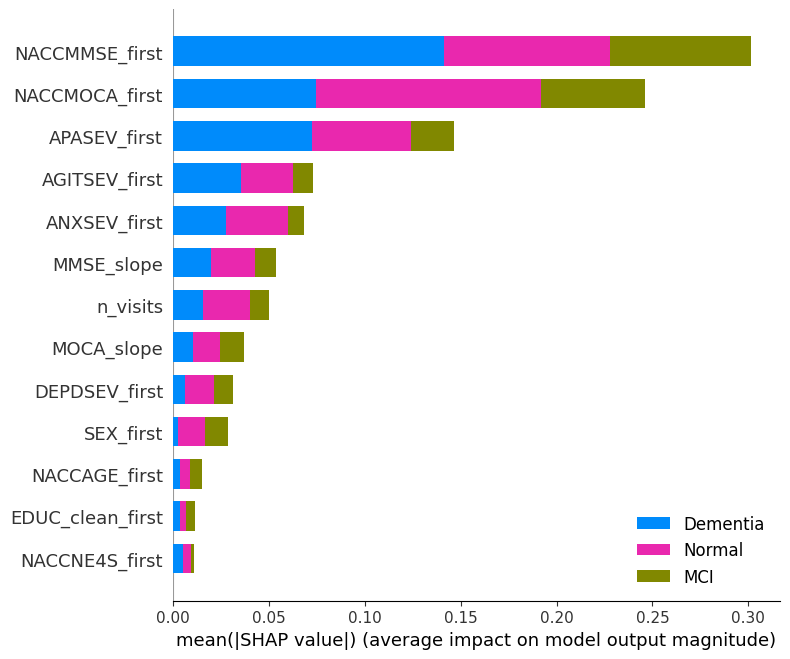


Plot 2: Bar Plot — mean absolute SHAP per class


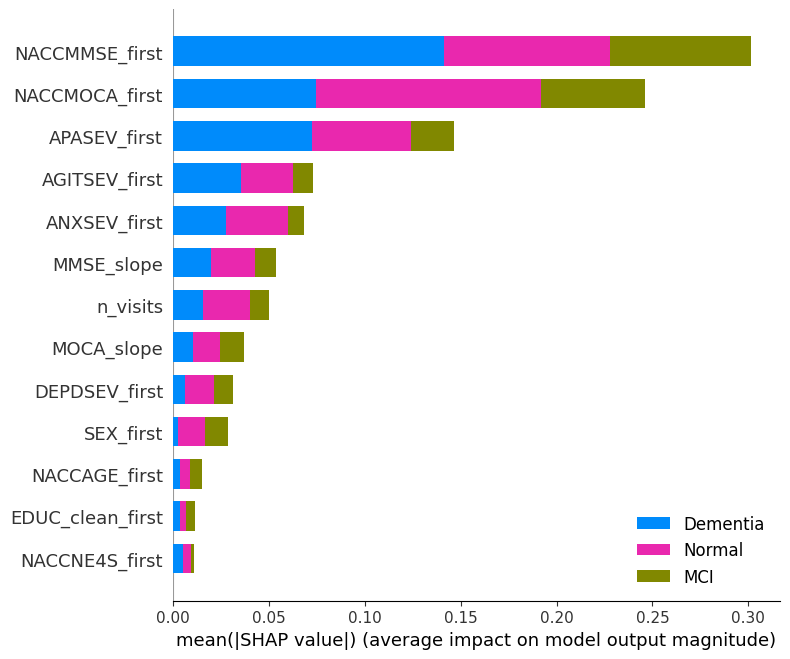


Plot 3: Waterfall — single Normal patient


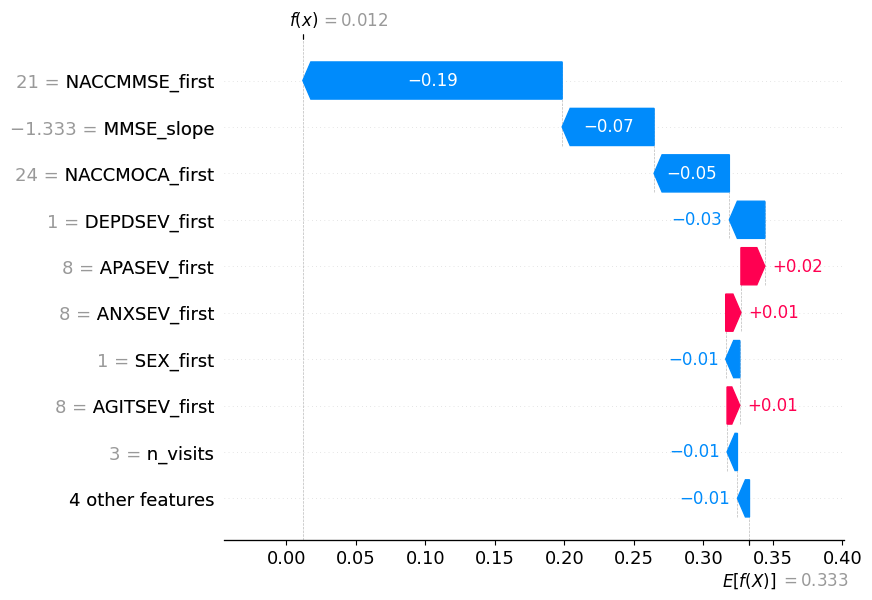


Plot 4: Waterfall — single Dementia patient


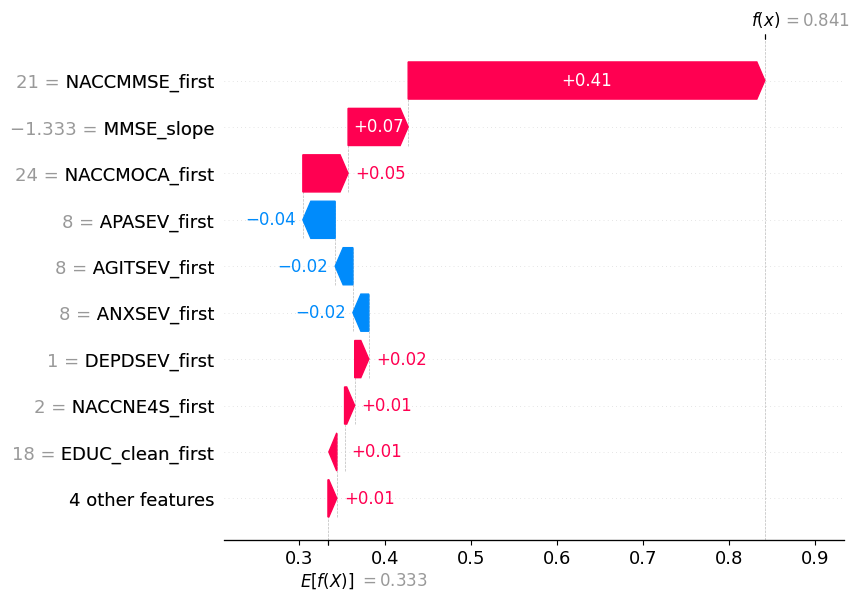


Plot 5: Dependence Plot — MMSE effect on Dementia prediction


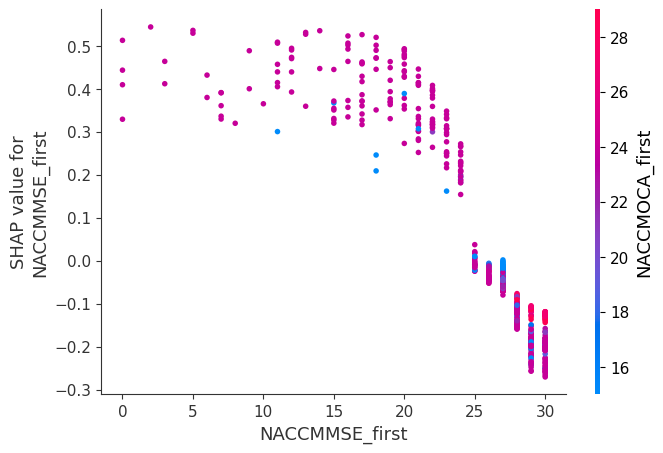

In [ ]:
# ENSEMBLE + SHAP (with SMOTENC-resampled training data)
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# STACKING ENSEMBLE (RF + GB → Logistic Regression meta-model)
print("Training Stacking Ensemble...")
estimators = [
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=10,
                                  random_state=42)),
    ("gb", GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                      learning_rate=0.05, random_state=42))
]
ensemble = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

ensemble.fit(X_train_sm, y_train_sm)
y_pred_ens = ensemble.predict(X_test_raw)
acc_ens = accuracy_score(y_test, y_pred_ens)
results["ENSEMBLE: Stacking (RF + GB → LR)"] = acc_ens

print(f"\n{'='*55}")
print(f"  ENSEMBLE: Stacking (RF + GB → LR)")
print(f"  Accuracy: {acc_ens:.4f}")
print(f"{'='*55}")
print(classification_report(y_test, y_pred_ens,
      target_names=["Normal", "MCI", "Dementia"],
      zero_division=0))

# FINAL MODEL COMPARISON
print("\n FINAL MODEL COMPARISON ")
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(acc * 40)
    print(f"{name[:52]:<52} {acc:.4f}  {bar}")

# SHAP ON RANDOM FOREST
print("\n\n SHAP Analysis (Random Forest + SMOTENC) ")
print("Fitting SHAP TreeExplainer on Random Forest...")

# Retrain RF standalone for SHAP (needed if m8 not in scope)
rf_for_shap = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_for_shap.fit(X_train_sm, y_train_sm)

# Sample test data for speed
shap_sample = X_test_raw.sample(n=min(1000, len(X_test_raw)), random_state=42).reset_index(drop=True)

explainer = shap.TreeExplainer(rf_for_shap)
shap_values = explainer(shap_sample)

# Plot 1 — Summary Plot
print("\nPlot 1: Summary Plot — global feature importance")
shap.summary_plot(shap_values, shap_sample,
                  class_names=["Normal", "MCI", "Dementia"],
                  show=True)

# Plot 2 — Bar Plot
print("\nPlot 2: Bar Plot — mean absolute SHAP per class")
shap.summary_plot(shap_values, shap_sample,
                  class_names=["Normal", "MCI", "Dementia"],
                  plot_type="bar", show=True)

# Plot 3 — Waterfall for one Normal patient
print("\nPlot 3: Waterfall — single Normal patient")
shap.plots.waterfall(shap_values[0, :, 0])

# Plot 4 — Waterfall for one Dementia patient
print("\nPlot 4: Waterfall — single Dementia patient")
shap.plots.waterfall(shap_values[0, :, 2])

# Plot 5 — Dependence plot MMSE vs MoCA
print("\nPlot 5: Dependence Plot — MMSE effect on Dementia prediction")
if "NACCMMSE_first" in feature_cols and "NACCMOCA_first" in feature_cols:
    shap.dependence_plot(
        "NACCMMSE_first",
        shap_values.values[:, :, 2],
        shap_sample,
        interaction_index="NACCMOCA_first"
    )

Stacking ensemble combines Random Forest and Gradient Boosting feeding into a Logistic Regression meta-model, achieving 71.5%, essentially tied with Gradient Boosting baseline.

Plot 1 and 2 — Bar Charts: NACCMMSE_first is the most important feature across all three classes, followed by NACCMOCA_first and APASEV_first in third place, validating the EDA finding that apathy carries real signal beyond just cognitive scores.

Plot 3 — Waterfall (Normal): A patient with MMSE 21 and declining slope gets a Normal probability of only 1.5%. Cognitive features dominate and push the prediction strongly away from Normal.

Plot 4 — Waterfall (Dementia): The same patient gets an 84.6% Dementia probability, driven almost entirely by the low MMSE score which contributes a SHAP value of +0.42.

Plot 5 — Dependence Plot: MMSE below 22 strongly predicts Dementia, MMSE above 26 is protective, with a sharp transition around score 23 which is the critical clinical threshold this dataset reveals.